In [246]:
import numpy as np
from scipy import special
from scipy.optimize import curve_fit
from scipy.stats import uniform
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from tabulate import tabulate
import corner
import math
import matplotlib.pyplot as plt
from tqdm import tqdm

In [183]:
M33 = np.genfromtxt("m33_data.dat", dtype=None)
NGC2 = np.genfromtxt("ngc2403_data.dat", dtype=None)
NGC3 = np.genfromtxt("ngc3198_data.dat", dtype=None)

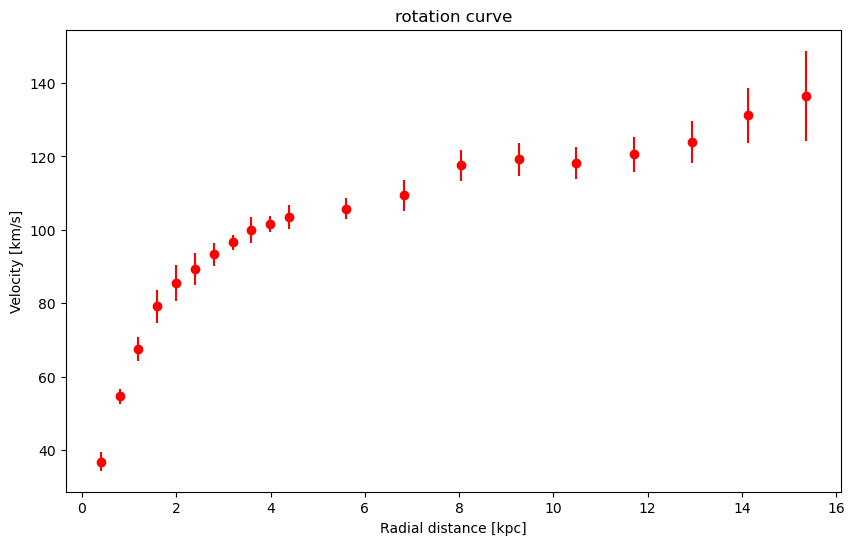

In [184]:
# define data set here
data = M33

%matplotlib inline

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro')
plt.title("rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.show()

In [185]:
# This is the exponential thin disk model of Freeman (1970)
def diskmodel(R,Rdisk,Mdisk):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39 # Mdisk is inputted in Giga Solar Masses, and converted to SI here
    rel = np.empty([len(R)])
    B = np.empty([len(R)])
    Vdisk=np.empty([len(R)])
    for i in range(len(R)):
        rel[i] = R[i]/Rdisk
        B[i] = (special.i0(0.5*rel[i]))*(special.k0(0.5*rel[i])) - (special.i1(0.5*rel[i]))*(special.k1(0.5*rel[i]))
        Vdisk[i] = 1e-3*np.sqrt( ( B[i]*rel[i]**2*Grv*Mdisk*GMSun )/( 2.0*Rdisk*kpc ) ) # Vdisk is outputted in km/s
    return Vdisk

In [186]:
# This is the Navarro, Frenk & White (1996) (NFW) halo profile
def halomodel(R,Rhalo,Mhalo):
    kpc=3.08567758149137e+19
    Grv=6.67408e-11
    GMSun=1.98855e39 # Mhalo is inputted in Giga Solar Masses, and converted to SI here
    rhohalo = 0.4120043135770753*(Mhalo*GMSun)/((Rhalo*kpc)**3) #0.412 comes from 1/2.4272 just below Eqn 17 of Sofue 2013
    rel=np.empty([len(R)])
    Mhalo=np.empty([len(R)])
    Vhalo=np.empty([len(R)])
    for i in range(len(R)):
        rel[i] = R[i]/Rhalo
        Mhalo[i] = 4.0*np.pi*rhohalo*(Rhalo*kpc)**3*( np.log(1.0+rel[i]) - rel[i]/(1.0+rel[i]) ) # Eqn 17 of Sofue 2013
        Vhalo[i] = 1e-3*np.sqrt( Grv*Mhalo[i]/(R[i]*kpc) ) # Vhalo is outputted in km/s, eqn 18 of Sofue 2013
    return Vhalo

In [187]:
# This simply adds the two velocity components together in quadrature
def rotnmodel(R,Rdisk,Mdisk,Rhalo,Mhalo):
    Vrot=np.empty([len(R)])
    Vdisk=np.empty([len(R)])
    Vhalo=np.empty([len(R)])
    Vdisk=diskmodel(R,Rdisk,Mdisk)
    Vhalo=halomodel(R,Rhalo,Mhalo)
    for i in range(len(R)):
        Vrot[i] = np.sqrt( Vdisk[i]**2 + Vhalo[i]**2 )
    return Vrot

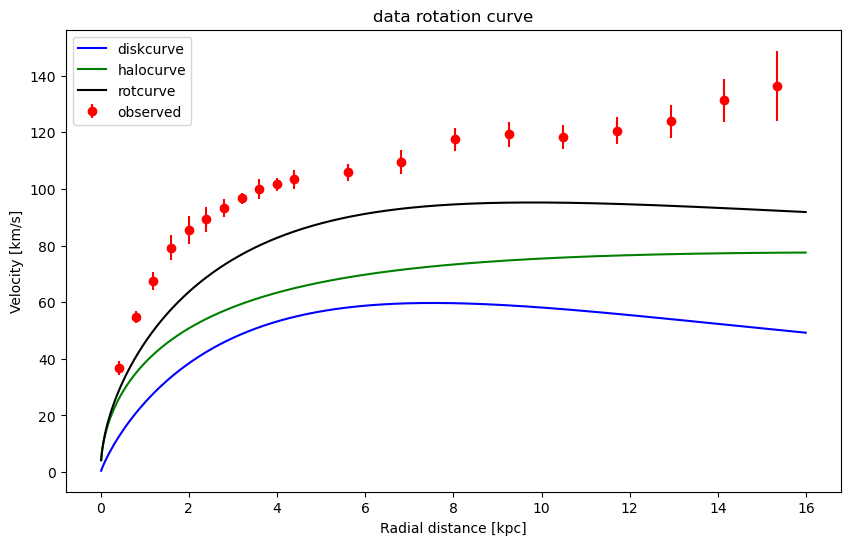

In [188]:
# define a high density list of R values to use
Rdense = np.arange(0.01,16,0.01)

# choose some inputs
Mdisk_test = 7.5 # Mass of the disk, in Giga-Solar-masses
Rdisk_test = 3.5 # Radius-scale parameter of the disk, in kilo-parsecs
Mhalo_test = 10.0 # Mass of the halo, in Giga-Solar-masses
Rhalo_test = 8.0 # Radius-scale parameter of the halo, in kilo-parsecs

# now just write out the equation derived in class
diskcurve = diskmodel(Rdense,Rdisk_test,Mdisk_test)
halocurve = halomodel(Rdense,Rhalo_test,Mhalo_test)
rotncurve = rotnmodel(Rdense,Rdisk_test,Mdisk_test,Rhalo_test,Mhalo_test)

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("data rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, diskcurve,'b-', label='diskcurve')
plt.plot(Rdense, halocurve,'g-', label='halocurve')
plt.plot(Rdense, rotncurve,'k-', label='rotcurve')
plt.legend()
plt.show()

In [189]:
# MOND model usin g
def mondmodel(R,Rdisk,Mdisk,acrit):
    kpc=3.08567758149137e+19
    Grv=6.67408e-11
    GMSun=1.98855e39 # Mdisk is inputted in Giga Solar Masses, and converted to SI here
    afac=1.0e-10     # acrit is inputted in 10^(-8)*cm/s^2, this converts to SI
    rel=np.empty([len(R)])
    B=np.empty([len(R)])
    gnewt=np.empty([len(R)])
    gmond=np.empty([len(R)])
    Vmond=np.empty([len(R)])
    for i in range(len(R)):
        rel[i] = R[i]/Rdisk
        B[i] = (special.i0(0.5*rel[i]))*(special.k0(0.5*rel[i])) - (special.i1(0.5*rel[i]))*(special.k1(0.5*rel[i]))
        gnewt[i] = ((Grv*Mdisk*GMSun)/(2.0*Rdisk*R[i]*kpc**2))*rel[i]**2*B[i]
        gmond[i] = np.sqrt( gnewt[i]**2 + np.sqrt( gnewt[i]**2*(4.0*(acrit*afac)**2+gnewt[i]**2) ) )/np.sqrt(2.0)
        Vmond[i] = 1e-3*np.sqrt( gmond[i]*R[i]*kpc ) # Vmond is outputted in km/s
    return Vmond

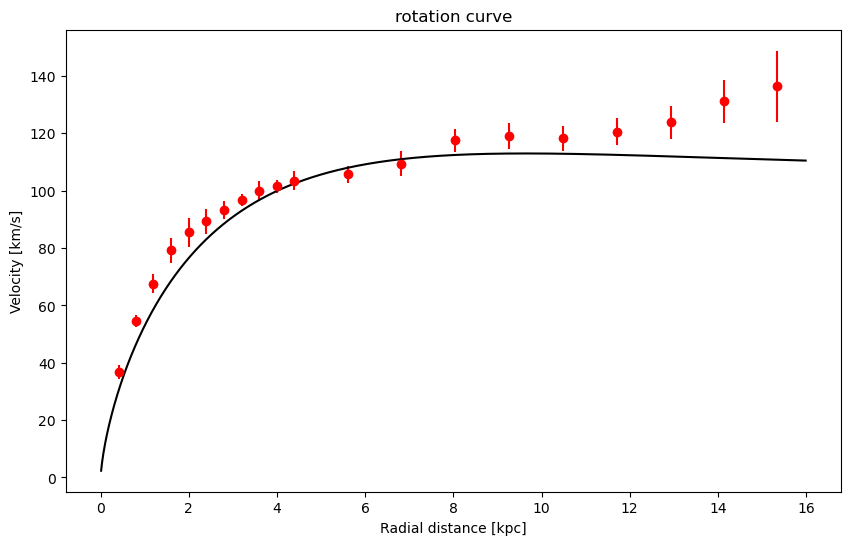

In [190]:
# define a high density list of R values to use
Rdense = np.arange(0.01,16,0.01)

# choose some inputs
Rdisk_test = 2.3   # Radius-scale parameter of the disk, in kilo-parsecs
Mdisk_test = 7.5   # Mass of the disk, in Giga-Solar-masses
acrit_test = 1.3   # Critical gravity, in cm/s * 10^-8

# now just write out the equation derived in class
mondcurve = mondmodel(Rdense,Rdisk_test,Mdisk_test,acrit_test)

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro')
plt.title("rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, mondcurve,'k-')
plt.show()

disk χ2 min:	 143.29
best Rdisk:	 3.39
best Mdisk:	 29.11

halo χ2 min:	 12.96
best Rhalo:	 7.84
best Mhalo:	 24.82

rotn χ2 min:	 12.73
best Rdisk:	 37.22
best Mdisk:	 100.0
best Rhalo:	 7.24
best Mhalo:	 21.54

mond χ2 min:	 32.45
best Rdisk:	 1.94
best Mdisk:	 0.11
best acrit:	 100.0


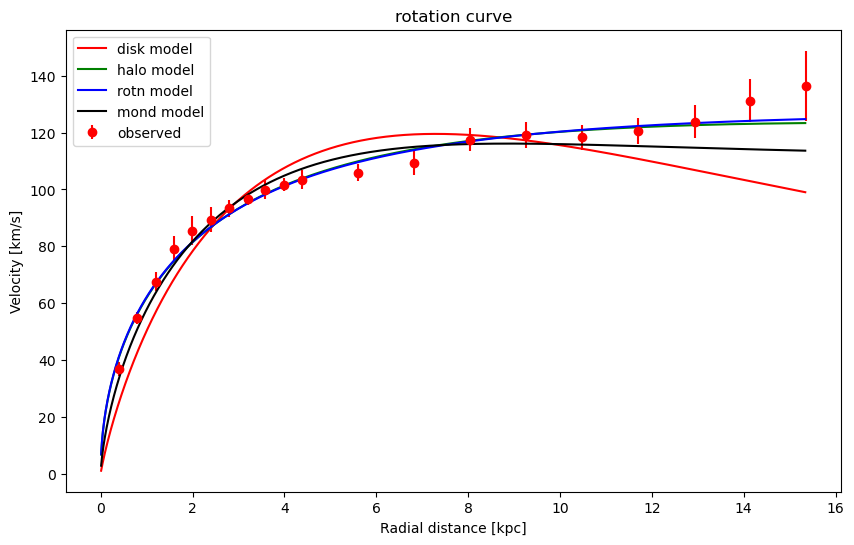

In [191]:
# Chi2 Minimization for data
# define data set here
data = M33
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# This is the exponential thin disk model of Freeman (1970)
def diskmodel(R, Rdisk, Mdisk):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39  # Mdisk is inputted in Giga Solar Masses, and converted to SI here
    rel = R / Rdisk
    B = (special.i0(0.5 * rel)) * (special.k0(0.5 * rel)) - (special.i1(0.5 * rel)) * (special.k1(0.5 * rel))
    Vdisk = 1e-3 * np.sqrt((B * rel**2 * Grv * Mdisk * GMSun) / (2.0 * Rdisk * kpc))  # Vdisk is outputted in km/s
    return Vdisk

# This is the Navarro, Frenk & White (1996) (NFW) halo profile
def halomodel(R, Rhalo, Mhalo):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39  # Mhalo is inputted in Giga Solar Masses, and converted to SI here
    rhohalo = 0.4120043135770753 * (Mhalo * GMSun) / ((Rhalo * kpc) ** 3)
    rel = R / Rhalo
    Mhalo = 4.0 * np.pi * rhohalo * (Rhalo * kpc) ** 3 * (np.log(1.0 + rel) - rel / (1.0 + rel))
    Vhalo = 1e-3 * np.sqrt(Grv * Mhalo / (R * kpc))  # Vhalo is outputted in km/s
    return Vhalo

# This simply adds the two velocity components together in quadrature
def rotnmodel(R, Rdisk, Mdisk, Rhalo, Mhalo):
    Vdisk = diskmodel(R, Rdisk, Mdisk)
    Vhalo = halomodel(R, Rhalo, Mhalo)
    Vrot = np.sqrt(Vdisk ** 2 + Vhalo ** 2)
    return Vrot

# MOND model usin g
def mondmodel(R, Rdisk, Mdisk, acrit):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39
    afac = 1.0e-10
    rel = R / Rdisk
    B = (special.i0(0.5 * rel) * special.k0(0.5 * rel)) - (special.i1(0.5 * rel) * special.k1(0.5 * rel))
    gnewt = ((Grv * Mdisk * GMSun) / (2.0 * Rdisk * R * kpc ** 2)) * rel ** 2 * B
    gmond = np.sqrt(gnewt ** 2 + np.sqrt(gnewt ** 2 * (4.0 * (acrit * afac) ** 2 + gnewt ** 2))) / np.sqrt(2.0)
    Vmond = 1e-3 * np.sqrt(gmond * R * kpc)
    return Vmond

# diskmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100

prior_bounds_disk = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_disk = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# halomodel
# Rhalo
min0, max0 = 0, 100
# Mhalo
min1, max1 = 0, 100

prior_bounds_halo = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_halo = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# rotnmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# Rhalo
min2, max2 = 0, 100
# Mhalo
min3, max3 = 0, 100

prior_bounds_rotn = np.array([[min0, min1, min2, min3],
                              [max0, max1, max2, max3]])
initial_guess_rotn = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2),
                      np.random.uniform(min3,max3)]

# mondmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# acrit
min2, max2 = 0, 100

prior_bounds_mond = np.array([[min0, min1, min2],
                              [max0, max1, max2]])
initial_guess_mond = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2)]

# Get the best fitting parameters for diskmodel
diskBest, diskcov = curve_fit(diskmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_disk,bounds=prior_bounds_disk,
                              maxfev=1000)

# Get the best fitting parameters for halomodel
haloBest, halocov = curve_fit(halomodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_halo,bounds=prior_bounds_halo,
                              maxfev=1000)

# Get the best fitting parameters for rotnmodel
rotnBest, rotncov = curve_fit(rotnmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_rotn,bounds=prior_bounds_rotn,
                              maxfev=1000)

# Get the best fitting parameters for mondmodel
mondBest, mondcov = curve_fit(mondmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_mond,bounds=prior_bounds_mond,
                              maxfev=1000)
# disk model chi2
disk = 0.0
for i in range(len(data)):
    disk = disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2
# halo model chi2
halo = 0.0
for i in range(len(data)):
    halo = halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
# rotn model chi2
rotn = 0.0
for i in range(len(data)):
    rotn = rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
# mond model chi2
mond = 0.0
for i in range(len(data)):
    mond = mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2
# disk model chi2
print("disk χ2 min:\t", np.round(disk,2))
print("best Rdisk:\t", np.round(diskBest[0],2))
print("best Mdisk:\t", np.round(diskBest[1],2))
print()
# halo model chi2
print("halo χ2 min:\t", np.round(halo,2))
print("best Rhalo:\t", np.round(haloBest[0],2))
print("best Mhalo:\t", np.round(haloBest[1],2))
print()
# rotn model chi2
print("rotn χ2 min:\t", np.round(rotn,2))
print("best Rdisk:\t", np.round(rotnBest[0],2))
print("best Mdisk:\t", np.round(rotnBest[1],2))
print("best Rhalo:\t", np.round(rotnBest[2],2))
print("best Mhalo:\t", np.round(rotnBest[3],2))
print()
# mond model chi2
print("mond χ2 min:\t", np.round(mond,2))
print("best Rdisk:\t", np.round(mondBest[0],2))
print("best Mdisk:\t", np.round(mondBest[1],2))
print("best acrit:\t", np.round(mondBest[2],2))

diskcurve = diskmodel(Rdense,diskBest[0],diskBest[1])
halocurve = halomodel(Rdense,haloBest[0],haloBest[1])
rotncurve = rotnmodel(Rdense,rotnBest[0],rotnBest[1],rotnBest[2],rotnBest[3])
mondcurve = mondmodel(Rdense,mondBest[0],mondBest[1],mondBest[2])

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, diskcurve,'r-', label='disk model')
plt.plot(Rdense, halocurve,'g-', label='halo model')
plt.plot(Rdense, rotncurve,'b-', label='rotn model')
plt.plot(Rdense, mondcurve,'k-', label='mond model')
plt.legend()
plt.show()

mond model performs the best via chi2 minimization

100%|██████████| 99999/99999 [00:07<00:00, 13753.69it/s]


loglike error:  -63.116
Rdisk mu:	 1.972
Mdisk mu:	 2.883
acrit mu:	 3.945
MCMC χ2:	 32.991


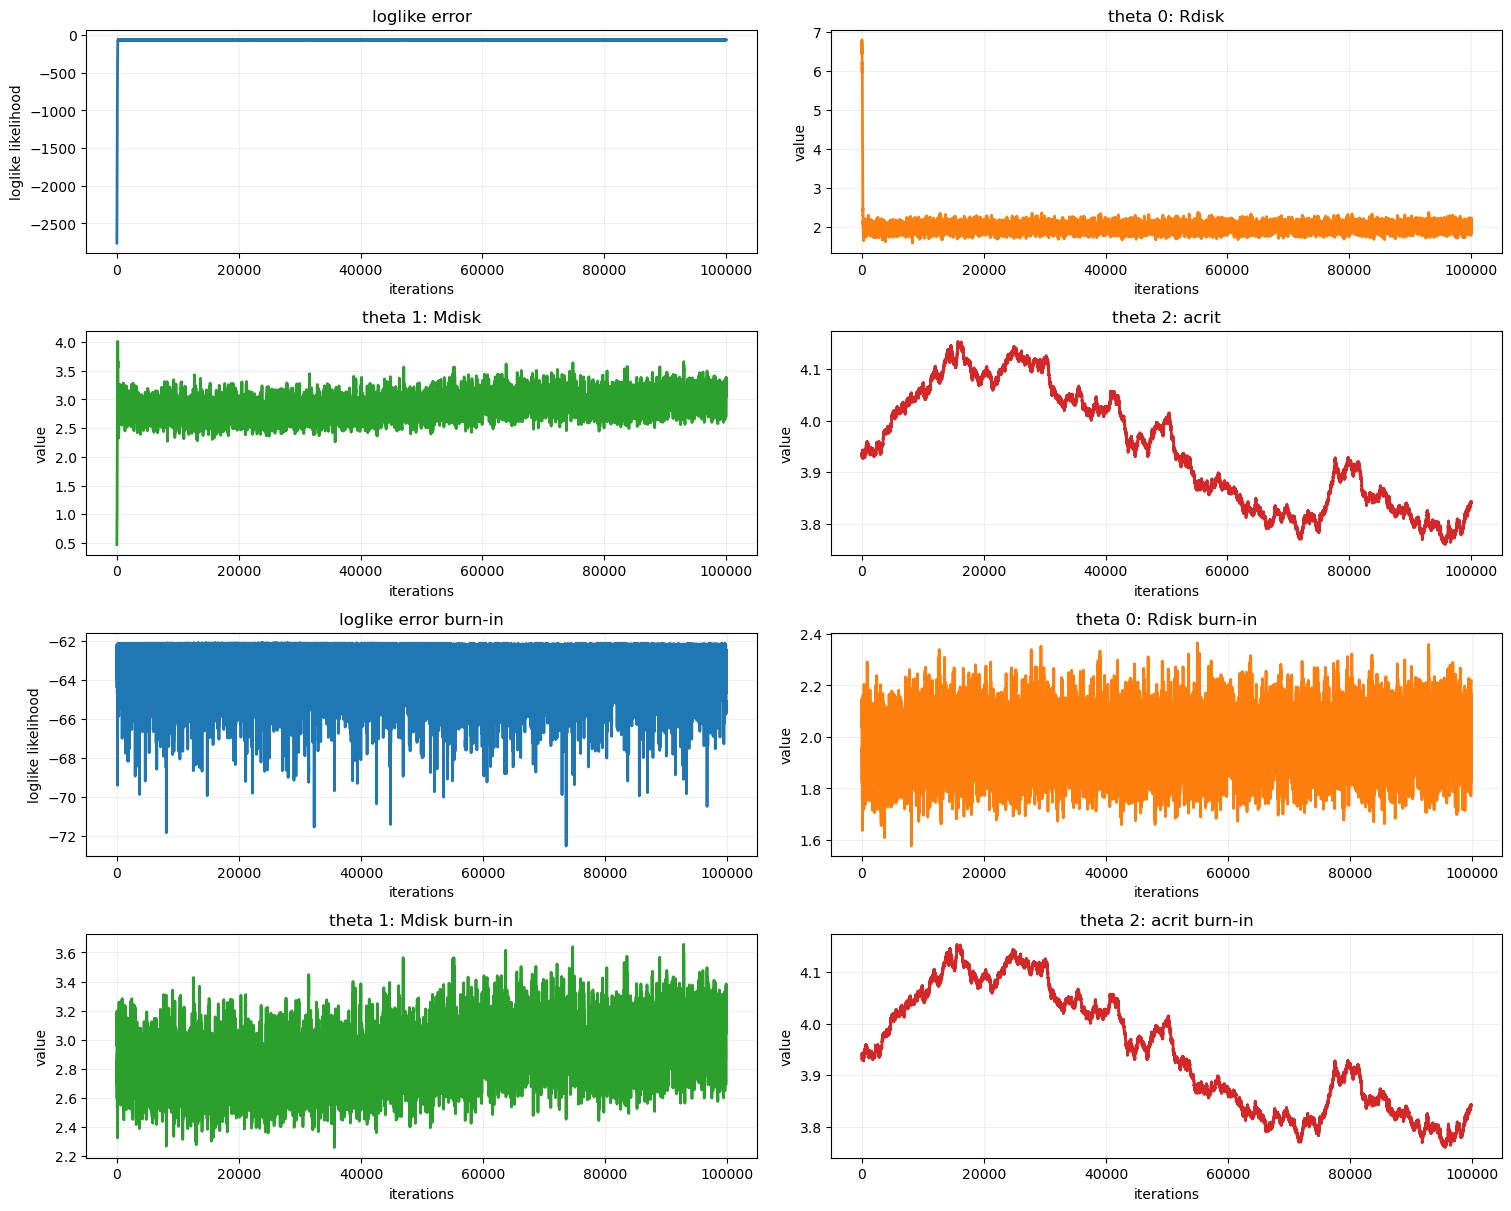

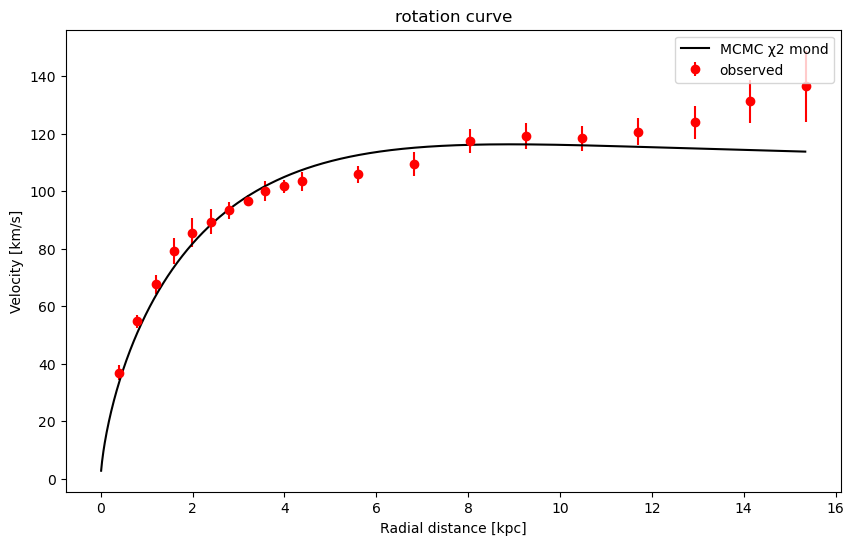

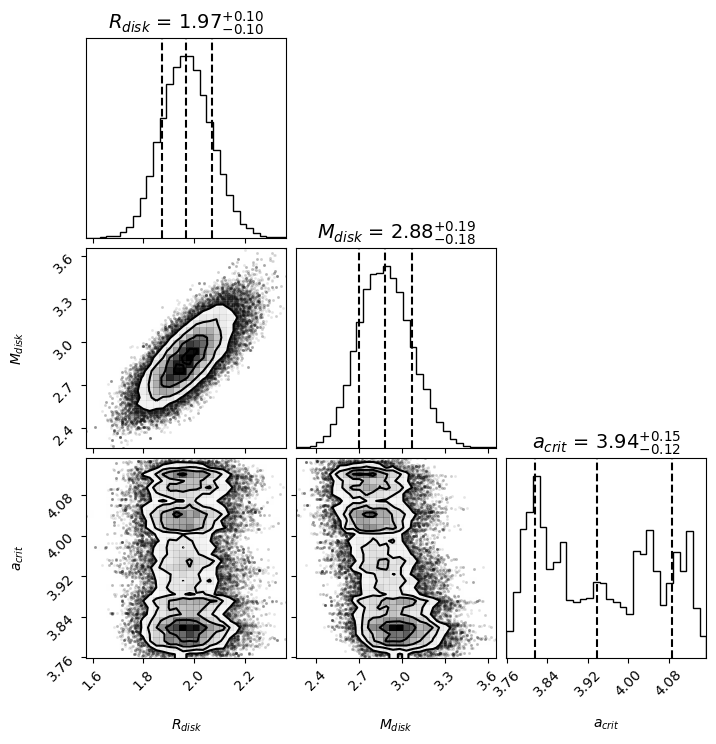

In [244]:
# MCMC 1

# define data set here
data = M33
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# MOND model usin g
def model(R, Rdisk, Mdisk, acrit):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39
    afac = 1.0e-10
    rel = R / Rdisk
    B = (special.i0(0.5 * rel) * special.k0(0.5 * rel)) - (special.i1(0.5 * rel) * special.k1(0.5 * rel))
    gnewt = ((Grv * Mdisk * GMSun) / (2.0 * Rdisk * R * kpc ** 2)) * rel ** 2 * B
    gmond = np.sqrt(gnewt ** 2 + np.sqrt(gnewt ** 2 * (4.0 * (acrit * afac) ** 2 + gnewt ** 2))) / np.sqrt(2.0)
    Vmond = 1e-3 * np.sqrt(gmond * R * kpc)
    return Vmond

def log_like(data, theta):
    y_model = model(data[:, 0], theta[0], theta[1], theta[2])
    loglike = -0.5 * np.log(2 * np.pi) - np.log(data[:, 2]) - 0.5 * ((data[:, 1] - y_model) / data[:, 2]) ** 2
    return np.sum(loglike)

def log_prior(theta, thetaspace):
    logprior = 0.0
    # Prior for theta[0]: Rdisk~logU[0, 20]
    if thetaspace[0][0] <= theta[0] < thetaspace[0][1]:
        logprior += -np.log(thetaspace[0][1] - thetaspace[0][0])
    else:
        return 1e-50000

    # Prior for theta[1]: Mdisk~logU[0, 100]
    if thetaspace[1][0] <= theta[1] < thetaspace[1][1]:
        logprior += -np.log(thetaspace[1][1] - thetaspace[1][0])
    else:
        return 1e-50000

    # Prior for theta[2]: acrit~logU[-2pi, 2pi]
    if thetaspace[2][0] <= theta[2] < thetaspace[2][1]:
        logprior += -np.log(thetaspace[2][1] - thetaspace[2][0])
    else:
        return 1e-50000
    
    return logprior

# Initialize the MCMC from a random point drawn from the prior using chi2 to inform priors
# Mdisk
min0, max0 = 0, 10
# Rdisk
min1, max1 = 0, 10
# acrit
min2, max2 = 0, 10

prior_params = np.array((min0, max0, min1, max1, min2, max2)).reshape(3, 2)

theta0 = np.random.uniform(min0, max0)
theta1 = np.random.uniform(min1, max1)
theta2 = np.random.uniform(min2, max2)

theta = np.array([theta0, theta1, theta2])

mod_loglike = log_like(data, theta)
mod_logp = mod_loglike + log_prior(theta, prior_params)

# Define proposal jump size:
delta = [max0*0.01, max1*0.01, max2*0.0001]

# Start walking
jmax = 100000
theta_j = np.zeros((jmax, 3))
loglike_j = np.zeros(jmax)
logp_j = np.zeros(jmax)

theta_j[0] = theta
loglike_j[0] = mod_loglike
logp_j[0] = mod_logp

for j in tqdm(range(1,jmax)):
    
    # Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial = np.random.normal(theta_j[j - 1], np.abs(delta))
    loglike_trial = log_like(data, theta_trial)
    logp_trial = loglike_trial + log_prior(theta_trial, prior_params)

    # Compute Metropolis rule
    if loglike_trial > loglike_j[j - 1] or np.random.rand() < np.exp(loglike_trial - loglike_j[j - 1]):
        theta_j[j] = theta_trial
        loglike_j[j] = loglike_trial
    else:
        theta_j[j] = theta_j[j - 1]
        loglike_j[j] = loglike_j[j - 1]
        logp_j[j] = logp_j[j - 1]
    
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = loglike_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if loglike_j[i] > median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []
theta_j_2 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    theta_j_2.append(i[2])
    iters = loglike_j[0]

theta_j = np.array(theta_j)
theta_names = ['theta 1', 'theta 2', 'theta 3']

plt.rcParams.update(plt.rcParamsDefault)
fig, axs = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
plt.ticklabel_format(useOffset=False)

axs[0, 0].plot(loglike_j, 'tab:blue', linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, 'tab:orange', linewidth=2)
axs[0, 1].set_title('theta 0: Rdisk')
axs[0, 1].set_xlabel('iterations')
axs[0, 1].set_ylabel('value')

axs[1, 0].plot(theta_j_1, 'tab:green', linewidth=2)
axs[1, 0].set_title('theta 1: Mdisk')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('value')

axs[1, 1].plot(theta_j_2, 'tab:red', linewidth=2)
axs[1, 1].set_title('theta 2: acrit')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(loglike_j[burn:], 'tab:blue', linewidth=2)
axs[2, 0].set_title('loglike error burn-in')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('loglike likelihood')

axs[2, 1].plot(theta_j_0[burn:], 'tab:orange', linewidth=2)
axs[2, 1].set_title('theta 0: Rdisk burn-in')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

axs[3, 0].plot(theta_j_1[burn:], 'tab:green', linewidth=2)
axs[3, 0].set_title('theta 1: Mdisk burn-in')
axs[3, 0].set_xlabel('iterations')
axs[3, 0].set_ylabel('value')

axs[3, 1].plot(theta_j_2[burn:], 'tab:red', linewidth=2)
axs[3, 1].set_title('theta 2: acrit burn-in')
axs[3, 1].set_xlabel('iterations')
axs[3, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# Plot corner diagram of the gradients and y-intercepts to find their expected correlation.
num = jmax-burn

loglikeErr = np.array(loglike_j[burn:]).reshape(num,1)
RdiskMCMC = np.array(theta_j_0[burn:]).reshape(num,1)
MdiskMCMC = np.array(theta_j_1[burn:]).reshape(num,1)
acritMCMC = np.array(theta_j_2[burn:]).reshape(num,1)

LLErr_mean = np.mean(loglikeErr)
Rdisk_mean = np.mean(RdiskMCMC)
Mdisk_mean = np.mean(MdiskMCMC)
acrit_mean = np.mean(acritMCMC)

samples = np.hstack([RdiskMCMC, MdiskMCMC, acritMCMC])

chi2MC = 0.0
for i in range(len(data)):
    chi2MC = chi2MC + ((data[i,1] - mondmodel(data[i,0],
                                              Rdisk_mean,
                                              Mdisk_mean,
                                              acrit_mean)) / data[i,2])**2

print("loglike error: ", np.round(LLErr_mean,3))
print("Rdisk mu:\t", np.round(Rdisk_mean,3))
print("Mdisk mu:\t", np.round(Mdisk_mean,3))
print("acrit mu:\t", np.round(acrit_mean,3))
print("MCMC χ2:\t", np.round(chi2MC,3))

mondcurve = mondmodel(Rdense,Rdisk_mean,Mdisk_mean,acrit_mean)

fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("M33 rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, mondcurve,'k-', label='MCMC χ2 mond')
plt.legend()
plt.show()

figure = corner.corner(samples, bins=30, labels=[
        r"$R_{disk}$",
        r"$M_{disk}$",
        r"$a_{crit}$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 14})

100%|██████████| 99999/99999 [00:07<00:00, 13391.38it/s]


loglike error:  -100.094
Rdisk mu:	 2.546
Mdisk mu:	 6.744
acrit mu:	 2.97
MCMC χ2 min:	 77.506


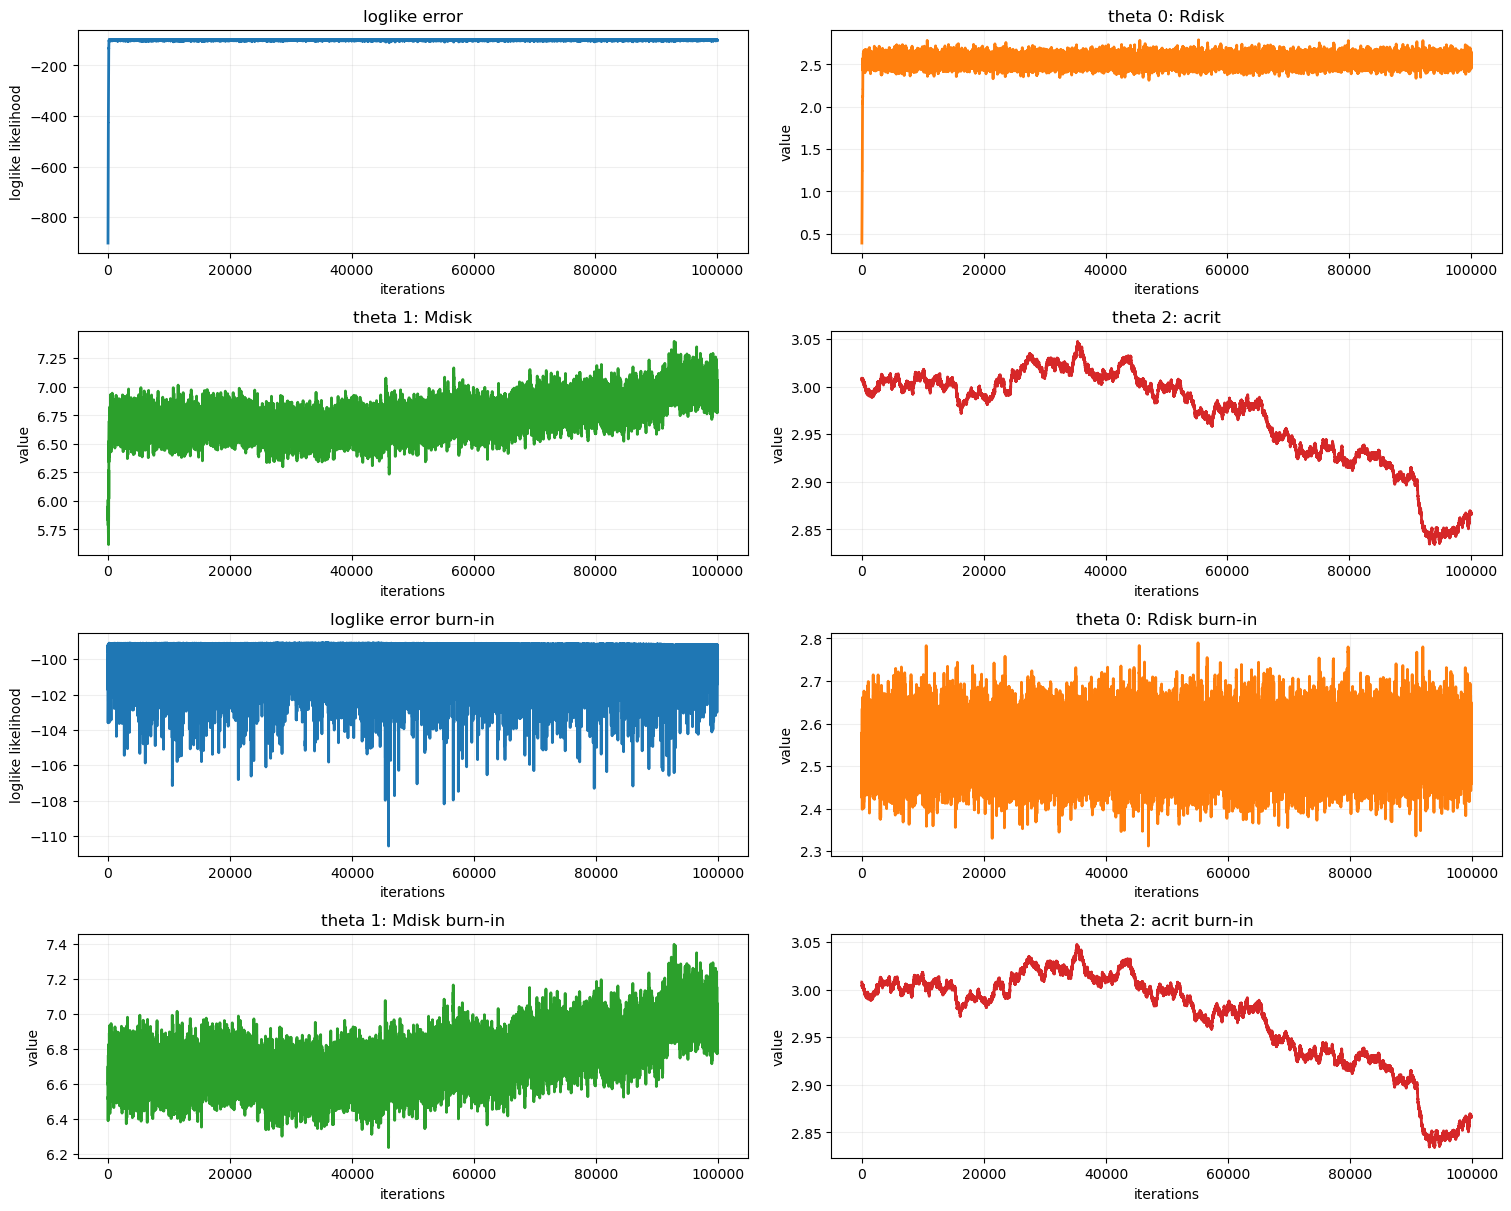

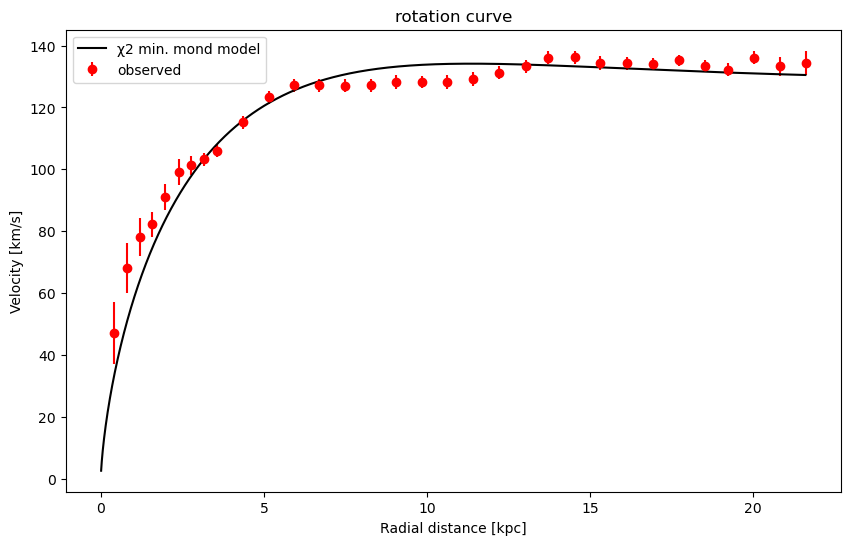

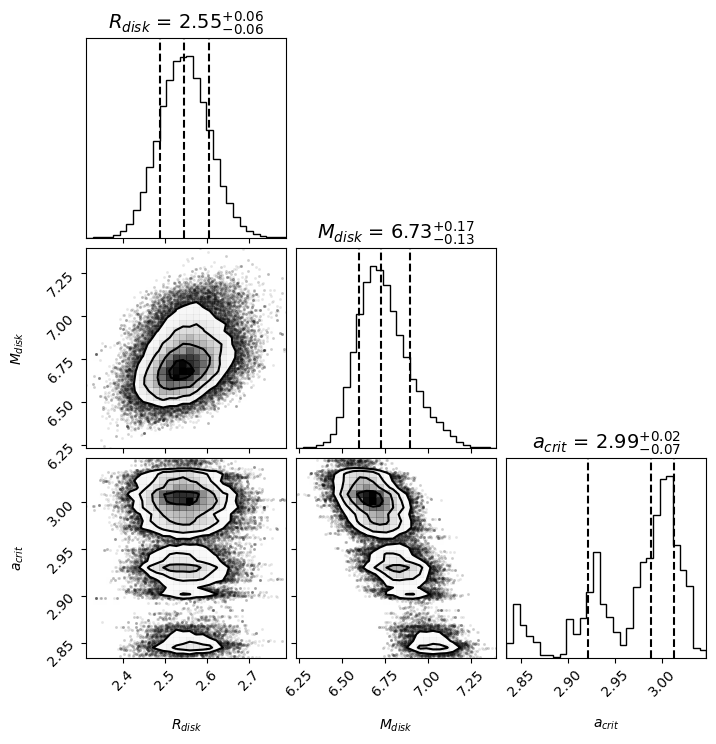

In [240]:
# MCMC 2

# define data set here
data = NGC2
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# MOND model usin g
def model(R, Rdisk, Mdisk, acrit):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39
    afac = 1.0e-10
    rel = R / Rdisk
    B = (special.i0(0.5 * rel) * special.k0(0.5 * rel)) - (special.i1(0.5 * rel) * special.k1(0.5 * rel))
    gnewt = ((Grv * Mdisk * GMSun) / (2.0 * Rdisk * R * kpc ** 2)) * rel ** 2 * B
    gmond = np.sqrt(gnewt ** 2 + np.sqrt(gnewt ** 2 * (4.0 * (acrit * afac) ** 2 + gnewt ** 2))) / np.sqrt(2.0)
    Vmond = 1e-3 * np.sqrt(gmond * R * kpc)
    return Vmond

def log_like(data, theta):
    y_model = model(data[:, 0], theta[0], theta[1], theta[2])
    loglike = -0.5 * np.log(2 * np.pi) - np.log(data[:, 2]) - 0.5 * ((data[:, 1] - y_model) / data[:, 2]) ** 2
    return np.sum(loglike)

def log_prior(theta, thetaspace):
    logprior = 0.0
    # Prior for theta[0]: Rdisk~logU[0, 20]
    if thetaspace[0][0] <= theta[0] < thetaspace[0][1]:
        logprior += -np.log(thetaspace[0][1] - thetaspace[0][0])
    else:
        return 1e-50000

    # Prior for theta[1]: Mdisk~logU[0, 100]
    if thetaspace[1][0] <= theta[1] < thetaspace[1][1]:
        logprior += -np.log(thetaspace[1][1] - thetaspace[1][0])
    else:
        return 1e-50000

    # Prior for theta[2]: acrit~logU[-2pi, 2pi]
    if thetaspace[2][0] <= theta[2] < thetaspace[2][1]:
        logprior += -np.log(thetaspace[2][1] - thetaspace[2][0])
    else:
        return 1e-50000
    
    return logprior

# Initialize the MCMC from a random point drawn from the prior using chi2 to inform priors
# Mdisk
min0, max0 = 0, 4

# Rdisk
min1, max1 = 3, 7

# acrit
min2, max2 = 0, 4

prior_params = np.array((min0, max0, min1, max1, min2, max2)).reshape(3, 2)

theta0 = np.random.uniform(min0, max0)
theta1 = np.random.uniform(min1, max1)
theta2 = np.random.uniform(min2, max2)

theta = np.array([theta0, theta1, theta2])

mod_loglike = log_like(data, theta)
mod_logp = mod_loglike + log_prior(theta, prior_params)

# Define proposal jump size:
delta = [max0*0.01, max1*0.01, max2*0.0001]

# Start walking
jmax = 100000
theta_j = np.zeros((jmax, 3))
loglike_j = np.zeros(jmax)
logp_j = np.zeros(jmax)

theta_j[0] = theta
loglike_j[0] = mod_loglike
logp_j[0] = mod_logp

for j in tqdm(range(1,jmax)):
    
    # Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial = np.random.normal(theta_j[j - 1], np.abs(delta))
    loglike_trial = log_like(data, theta_trial)
    logp_trial = loglike_trial + log_prior(theta_trial, prior_params)

    # Compute Metropolis rule
    if loglike_trial > loglike_j[j - 1] or np.random.rand() < np.exp(loglike_trial - loglike_j[j - 1]):
        theta_j[j] = theta_trial
        loglike_j[j] = loglike_trial
    else:
        theta_j[j] = theta_j[j - 1]
        loglike_j[j] = loglike_j[j - 1]
        logp_j[j] = logp_j[j - 1]
    
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = loglike_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if loglike_j[i] > median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []
theta_j_2 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    theta_j_2.append(i[2])
    iters = loglike_j[0]

theta_j = np.array(theta_j)
theta_names = ['theta 1', 'theta 2', 'theta 3']

plt.rcParams.update(plt.rcParamsDefault)
fig, axs = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
plt.ticklabel_format(useOffset=False)

axs[0, 0].plot(loglike_j, 'tab:blue', linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, 'tab:orange', linewidth=2)
axs[0, 1].set_title('theta 0: Rdisk')
axs[0, 1].set_xlabel('iterations')
axs[0, 1].set_ylabel('value')

axs[1, 0].plot(theta_j_1, 'tab:green', linewidth=2)
axs[1, 0].set_title('theta 1: Mdisk')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('value')

axs[1, 1].plot(theta_j_2, 'tab:red', linewidth=2)
axs[1, 1].set_title('theta 2: acrit')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(loglike_j[burn:], 'tab:blue', linewidth=2)
axs[2, 0].set_title('loglike error burn-in')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('loglike likelihood')

axs[2, 1].plot(theta_j_0[burn:], 'tab:orange', linewidth=2)
axs[2, 1].set_title('theta 0: Rdisk burn-in')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

axs[3, 0].plot(theta_j_1[burn:], 'tab:green', linewidth=2)
axs[3, 0].set_title('theta 1: Mdisk burn-in')
axs[3, 0].set_xlabel('iterations')
axs[3, 0].set_ylabel('value')

axs[3, 1].plot(theta_j_2[burn:], 'tab:red', linewidth=2)
axs[3, 1].set_title('theta 2: acrit burn-in')
axs[3, 1].set_xlabel('iterations')
axs[3, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# Plot corner diagram of the gradients and y-intercepts to find their expected correlation.
num = jmax-burn

loglikeErr = np.array(loglike_j[burn:]).reshape(num,1)
RdiskMCMC = np.array(theta_j_0[burn:]).reshape(num,1)
MdiskMCMC = np.array(theta_j_1[burn:]).reshape(num,1)
acritMCMC = np.array(theta_j_2[burn:]).reshape(num,1)

LLErr_mean = np.mean(loglikeErr)
Rdisk_mean = np.mean(RdiskMCMC)
Mdisk_mean = np.mean(MdiskMCMC)
acrit_mean = np.mean(acritMCMC)

samples = np.hstack([RdiskMCMC, MdiskMCMC, acritMCMC])

chi2MC = 0.0
for i in range(len(data)):
    chi2MC = chi2MC + ((data[i,1] - mondmodel(data[i,0],
                                              Rdisk_mean,
                                              Mdisk_mean,
                                              acrit_mean)) / data[i,2])**2

print("loglike error: ", np.round(LLErr_mean,3))
print("Rdisk mu:\t", np.round(Rdisk_mean,3))
print("Mdisk mu:\t", np.round(Mdisk_mean,3))
print("acrit mu:\t", np.round(acrit_mean,3))
print("MCMC χ2:\t", np.round(chi2MC,3))

mondcurve = mondmodel(Rdense,Rdisk_mean,Mdisk_mean,acrit_mean)

fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("NGC2403 rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, mondcurve,'k-', label='MCMC χ2 mond')
plt.legend()
plt.show()

figure = corner.corner(samples, bins=30, labels=[
        r"$R_{disk}$",
        r"$M_{disk}$",
        r"$a_{crit}$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 14})

100%|██████████| 99999/99999 [00:06<00:00, 14680.32it/s]


loglike error:  -60.943
Rdisk mu:	 2.093
Mdisk mu:	 10.259
acrit mu:	 3.46
MCMC χ2:	 12.9


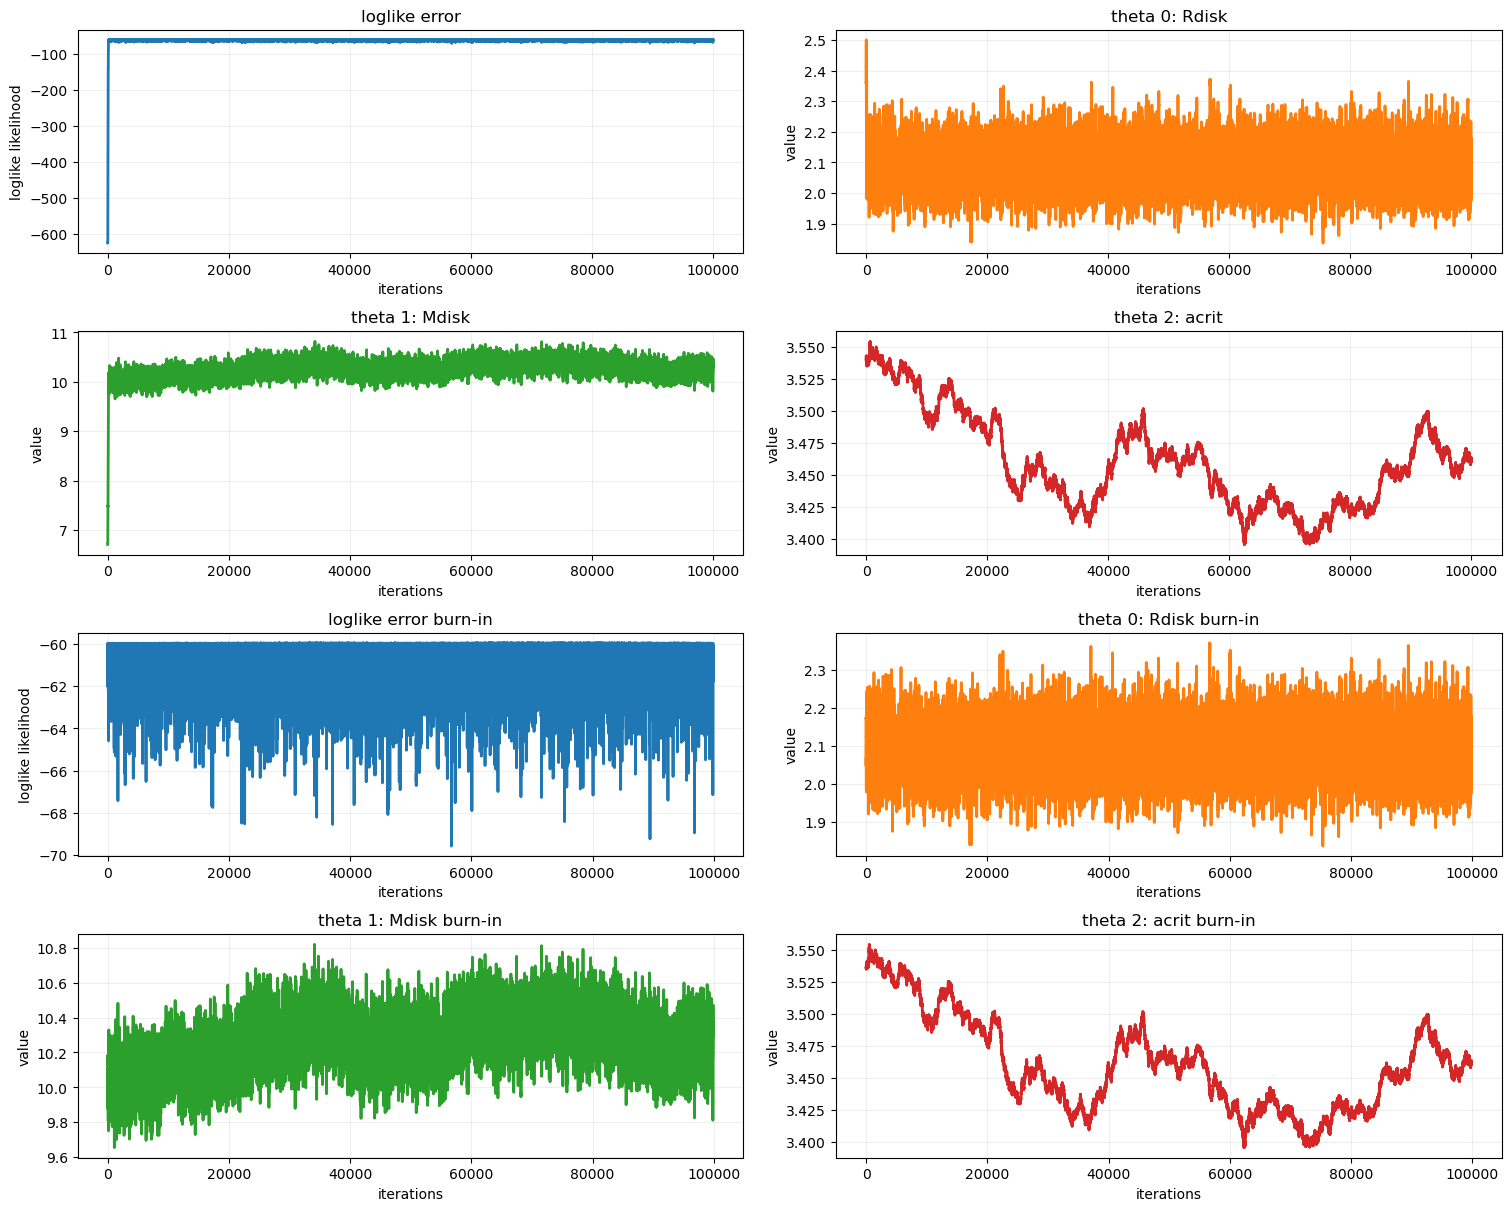

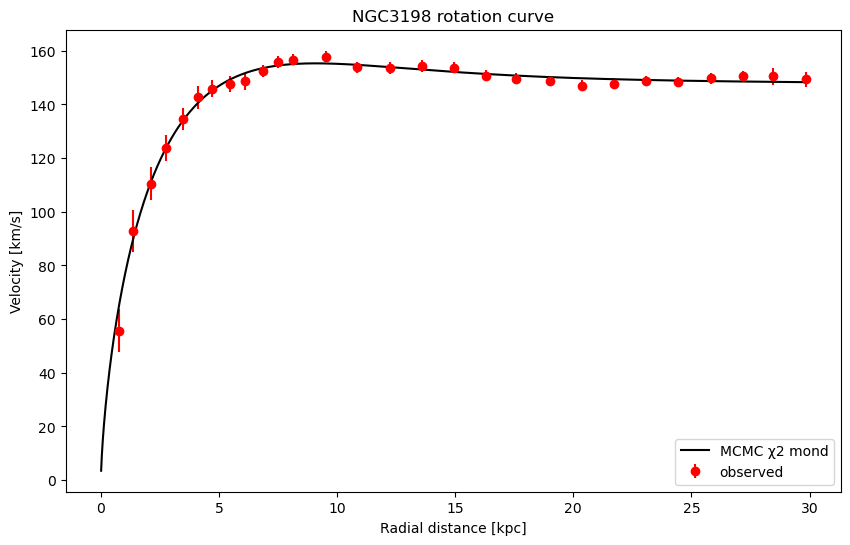

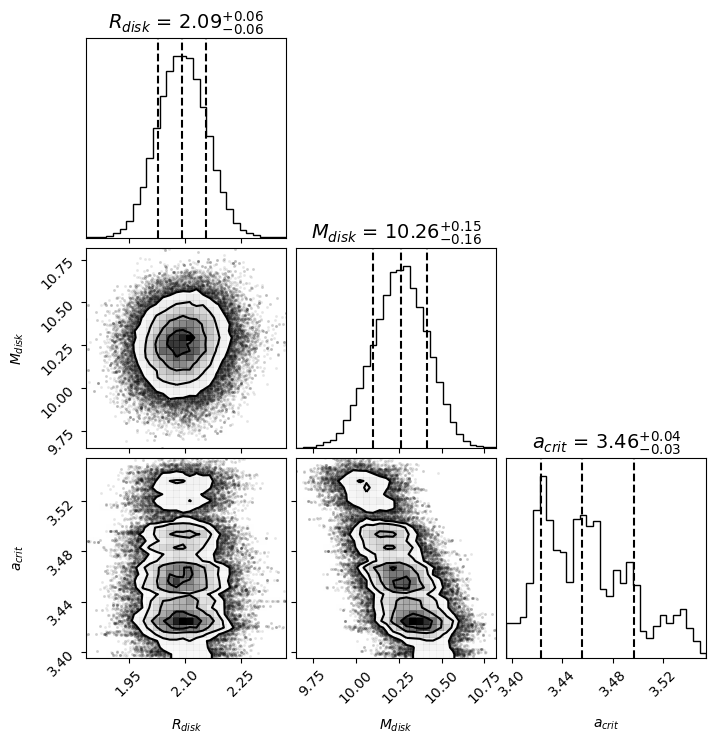

In [259]:
# MCMC 3

# define data set here
data = NGC3
Rdense = np.arange(0.01,data[:,0][-1],0.01)


# MOND model usin g
def model(R, Rdisk, Mdisk, acrit):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39
    afac = 1.0e-10
    rel = R / Rdisk
    B = (special.i0(0.5 * rel) * special.k0(0.5 * rel)) - (special.i1(0.5 * rel) * special.k1(0.5 * rel))
    gnewt = ((Grv * Mdisk * GMSun) / (2.0 * Rdisk * R * kpc ** 2)) * rel ** 2 * B
    gmond = np.sqrt(gnewt ** 2 + np.sqrt(gnewt ** 2 * (4.0 * (acrit * afac) ** 2 + gnewt ** 2))) / np.sqrt(2.0)
    Vmond = 1e-3 * np.sqrt(gmond * R * kpc)
    return Vmond

def log_like(data, theta):
    y_model = model(data[:, 0], theta[0], theta[1], theta[2])
    loglike = -0.5 * np.log(2 * np.pi) - np.log(data[:, 2]) - 0.5 * ((data[:, 1] - y_model) / data[:, 2]) ** 2
    return np.sum(loglike)

def log_prior(theta, thetaspace):
    logprior = 0.0
    # Prior for theta[0]: Rdisk~logU[0, 20]
    if thetaspace[0][0] <= theta[0] < thetaspace[0][1]:
        logprior += -np.log(thetaspace[0][1] - thetaspace[0][0])
    else:
        return 1e-50000

    # Prior for theta[1]: Mdisk~logU[0, 100]
    if thetaspace[1][0] <= theta[1] < thetaspace[1][1]:
        logprior += -np.log(thetaspace[1][1] - thetaspace[1][0])
    else:
        return 1e-50000

    # Prior for theta[2]: acrit~logU[-2pi, 2pi]
    if thetaspace[2][0] <= theta[2] < thetaspace[2][1]:
        logprior += -np.log(thetaspace[2][1] - thetaspace[2][0])
    else:
        return 1e-50000
    
    return logprior

# Initialize the MCMC from a random point drawn from the prior using chi2 to inform priors
# Mdisk
min0, max0 = 0, 4

# Rdisk
min1, max1 = 3, 7

# acrit
min2, max2 = 0, 4

prior_params = np.array((min0, max0, min1, max1, min2, max2)).reshape(3, 2)

theta0 = np.random.uniform(min0, max0)
theta1 = np.random.uniform(min1, max1)
theta2 = np.random.uniform(min2, max2)

theta = np.array([theta0, theta1, theta2])

mod_loglike = log_like(data, theta)
mod_logp = mod_loglike + log_prior(theta, prior_params)

# Define proposal jump size:
delta = [max0*0.01, max1*0.01, max2*0.0001]

# Start walking
jmax = 100000
theta_j = np.zeros((jmax, 3))
loglike_j = np.zeros(jmax)
logp_j = np.zeros(jmax)

theta_j[0] = theta
loglike_j[0] = mod_loglike
logp_j[0] = mod_logp

for j in tqdm(range(1,jmax)):
    
    # Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial = np.random.normal(theta_j[j - 1], np.abs(delta))
    loglike_trial = log_like(data, theta_trial)
    logp_trial = loglike_trial + log_prior(theta_trial, prior_params)

    # Compute Metropolis rule
    if loglike_trial > loglike_j[j - 1] or np.random.rand() < np.exp(loglike_trial - loglike_j[j - 1]):
        theta_j[j] = theta_trial
        loglike_j[j] = loglike_trial
    else:
        theta_j[j] = theta_j[j - 1]
        loglike_j[j] = loglike_j[j - 1]
        logp_j[j] = logp_j[j - 1]
    
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = loglike_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if loglike_j[i] > median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []
theta_j_2 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    theta_j_2.append(i[2])
    iters = loglike_j[0]

theta_j = np.array(theta_j)
theta_names = ['theta 1', 'theta 2', 'theta 3']

plt.rcParams.update(plt.rcParamsDefault)
fig, axs = plt.subplots(4, 2, figsize=(15, 12), constrained_layout=True)
plt.ticklabel_format(useOffset=False)

axs[0, 0].plot(loglike_j, 'tab:blue', linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, 'tab:orange', linewidth=2)
axs[0, 1].set_title('theta 0: Rdisk')
axs[0, 1].set_xlabel('iterations')
axs[0, 1].set_ylabel('value')

axs[1, 0].plot(theta_j_1, 'tab:green', linewidth=2)
axs[1, 0].set_title('theta 1: Mdisk')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('value')

axs[1, 1].plot(theta_j_2, 'tab:red', linewidth=2)
axs[1, 1].set_title('theta 2: acrit')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(loglike_j[burn:], 'tab:blue', linewidth=2)
axs[2, 0].set_title('loglike error burn-in')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('loglike likelihood')

axs[2, 1].plot(theta_j_0[burn:], 'tab:orange', linewidth=2)
axs[2, 1].set_title('theta 0: Rdisk burn-in')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

axs[3, 0].plot(theta_j_1[burn:], 'tab:green', linewidth=2)
axs[3, 0].set_title('theta 1: Mdisk burn-in')
axs[3, 0].set_xlabel('iterations')
axs[3, 0].set_ylabel('value')

axs[3, 1].plot(theta_j_2[burn:], 'tab:red', linewidth=2)
axs[3, 1].set_title('theta 2: acrit burn-in')
axs[3, 1].set_xlabel('iterations')
axs[3, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# Plot corner diagram of the gradients and y-intercepts to find their expected correlation.
num = jmax-burn

loglikeErr = np.array(loglike_j[burn:]).reshape(num,1)
RdiskMCMC = np.array(theta_j_0[burn:]).reshape(num,1)
MdiskMCMC = np.array(theta_j_1[burn:]).reshape(num,1)
acritMCMC = np.array(theta_j_2[burn:]).reshape(num,1)

LLErr_mean = np.mean(loglikeErr)
Rdisk_mean = np.mean(RdiskMCMC)
Mdisk_mean = np.mean(MdiskMCMC)
acrit_mean = np.mean(acritMCMC)

samples = np.hstack([RdiskMCMC, MdiskMCMC, acritMCMC])

chi2MC = 0.0
for i in range(len(data)):
    chi2MC = chi2MC + ((data[i,1] - mondmodel(data[i,0],
                                              Rdisk_mean,
                                              Mdisk_mean,
                                              acrit_mean)) / data[i,2])**2

print("loglike error: ", np.round(LLErr_mean,3))
print("Rdisk mu:\t", np.round(Rdisk_mean,3))
print("Mdisk mu:\t", np.round(Mdisk_mean,3))
print("acrit mu:\t", np.round(acrit_mean,3))
print("MCMC χ2:\t", np.round(chi2MC,3))

mondcurve = mondmodel(Rdense,Rdisk_mean,Mdisk_mean,acrit_mean)

fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("NGC3198 rotation curve")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, mondcurve,'k-', label='MCMC χ2 mond')
plt.legend()
plt.show()

figure = corner.corner(samples, bins=30, labels=[
        r"$R_{disk}$",
        r"$M_{disk}$",
        r"$a_{crit}$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 14})

In [195]:
# This is the exponential thin disk model of Freeman (1970)
def diskmodel(R, Rdisk, Mdisk):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39  # Mdisk is inputted in Giga Solar Masses, and converted to SI here
    rel = R / Rdisk
    B = (special.i0(0.5 * rel)) * (special.k0(0.5 * rel)) - (special.i1(0.5 * rel)) * (special.k1(0.5 * rel))
    Vdisk = 1e-3 * np.sqrt((B * rel**2 * Grv * Mdisk * GMSun) / (2.0 * Rdisk * kpc))  # Vdisk is outputted in km/s
    return Vdisk

# This is the Navarro, Frenk & White (1996) (NFW) halo profile
def halomodel(R, Rhalo, Mhalo):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39  # Mhalo is inputted in Giga Solar Masses, and converted to SI here
    rhohalo = 0.4120043135770753 * (Mhalo * GMSun) / ((Rhalo * kpc) ** 3)
    rel = R / Rhalo
    Mhalo = 4.0 * np.pi * rhohalo * (Rhalo * kpc) ** 3 * (np.log(1.0 + rel) - rel / (1.0 + rel))
    Vhalo = 1e-3 * np.sqrt(Grv * Mhalo / (R * kpc))  # Vhalo is outputted in km/s
    return Vhalo

# This simply adds the two velocity components together in quadrature
def rotnmodel(R, Rdisk, Mdisk, Rhalo, Mhalo):
    Vdisk = diskmodel(R, Rdisk, Mdisk)
    Vhalo = halomodel(R, Rhalo, Mhalo)
    Vrot = np.sqrt(Vdisk ** 2 + Vhalo ** 2)
    return Vrot

# MOND model usin g
def mondmodel(R, Rdisk, Mdisk, acrit):
    kpc = 3.08567758149137e+19
    Grv = 6.67408e-11
    GMSun = 1.98855e39
    afac = 1.0e-10
    rel = R / Rdisk
    B = (special.i0(0.5 * rel) * special.k0(0.5 * rel)) - (special.i1(0.5 * rel) * special.k1(0.5 * rel))
    gnewt = ((Grv * Mdisk * GMSun) / (2.0 * Rdisk * R * kpc ** 2)) * rel ** 2 * B
    gmond = np.sqrt(gnewt ** 2 + np.sqrt(gnewt ** 2 * (4.0 * (acrit * afac) ** 2 + gnewt ** 2))) / np.sqrt(2.0)
    Vmond = 1e-3 * np.sqrt(gmond * R * kpc)
    return Vmond

~disk model~
best Rdisk:	 3.39
best Mdisk:	 29.11
χ2 Min:		 143.29
Red. χ2:	 7.96
BIC:		 240.56
AIC:		 238.56

~halo model~
best Rhalo:	 7.84
best Mhalo:	 24.82
χ2 Min:		 12.96
Red. χ2:	 0.72
BIC:		 110.22
AIC:		 108.23

~rotn model~
best Rdisk:	 37.22
best Mdisk:	 100.0
best Rhalo:	 7.24
best Mhalo:	 21.54
χ2 Min:		 12.73
Red. χ2:	 0.8
BIC:		 115.99
AIC:		 112.0

~mond model~
best Rdisk:	 1.94
best Mdisk:	 1.14
best acrit:	 10.0
χ2 Min:		 32.53
Red. χ2:	 1.91
BIC:		 132.79
AIC:		 129.8


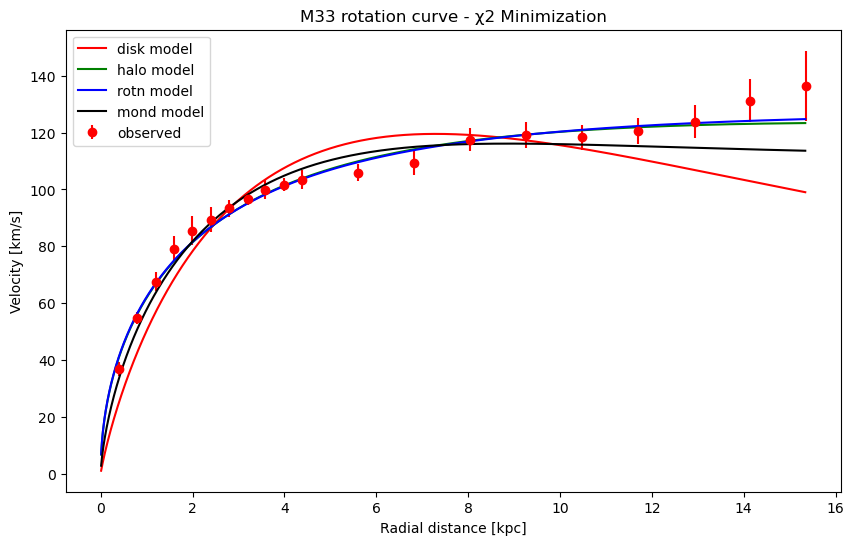

In [264]:
# Chi2 Minimization for data
# define data set here
data = M33
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# diskmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100

prior_bounds_disk = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_disk = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# halomodel
# Rhalo
min0, max0 = 0, 100
# Mhalo
min1, max1 = 0, 100

prior_bounds_halo = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_halo = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# rotnmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# Rhalo
min2, max2 = 0, 100
# Mhalo
min3, max3 = 0, 100

prior_bounds_rotn = np.array([[min0, min1, min2, min3],
                              [max0, max1, max2, max3]])
initial_guess_rotn = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2),
                      np.random.uniform(min3,max3)]

# mondmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# acrit
min2, max2 = 0, 10

prior_bounds_mond = np.array([[min0, min1, min2],
                              [max0, max1, max2]])
initial_guess_mond = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2)]

# Get the best fitting parameters for diskmodel
diskBest, diskcov = curve_fit(diskmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_disk,bounds=prior_bounds_disk,
                              maxfev=1000)

# Get the best fitting parameters for halomodel
haloBest, halocov = curve_fit(halomodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_halo,bounds=prior_bounds_halo,
                              maxfev=1000)

# Get the best fitting parameters for rotnmodel
rotnBest, rotncov = curve_fit(rotnmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_rotn,bounds=prior_bounds_rotn,
                              maxfev=1000)

# Get the best fitting parameters for mondmodel
mondBest, mondcov = curve_fit(mondmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_mond,bounds=prior_bounds_mond,
                              maxfev=1000)
# disk model chi2
disk = 0.0
for i in range(len(data)):
    disk = disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2
loglike_disk = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*disk
    

# halo model chi2
halo = 0.0
for i in range(len(data)):
    halo = halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
loglike_halo = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*halo

# rotn model chi2
rotn = 0.0
for i in range(len(data)):
    rotn = rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
loglike_rotn = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*rotn

# mond model chi2
mond = 0.0
for i in range(len(data)):
    mond = mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2
loglike_mond = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*mond

# disk model chi2
chi2_red_disk = 0.0
for i in range(len(data)):
    chi2_red_disk = chi2_red_disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2    
# halo model chi2
chi2_red_halo = 0.0
for i in range(len(data)):
    chi2_red_halo = chi2_red_halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
# rotn model chi2
chi2_red_rotn = 0.0
for i in range(len(data)):
    chi2_red_rotn = chi2_red_rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
# mond model chi2
chi2_red_mond = 0.0
for i in range(len(data)):
    chi2_red_mond = chi2_red_mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2

# Calculate the reduced chi2
chi2_red_disk = chi2_red_disk / (len(data)-len(diskBest))
chi2_red_halo = chi2_red_halo / (len(data)-len(haloBest))
chi2_red_rotn = chi2_red_rotn / (len(data)-len(rotnBest))
chi2_red_mond = chi2_red_mond / (len(data)-len(mondBest))

# Calculate the BIC and AIC
bic_disk = -2 * loglike_disk + len(diskBest) * np.log(len(data))
aic_disk = -2 * loglike_disk + 2 * len(diskBest)

bic_halo = -2 * loglike_halo + len(haloBest) * np.log(len(data))
aic_halo = -2 * loglike_halo + 2 * len(haloBest)

bic_rotn = -2 * loglike_rotn + len(rotnBest) * np.log(len(data))
aic_rotn = -2 * loglike_rotn + 2 * len(rotnBest)

bic_mond = -2 * loglike_mond + len(mondBest) * np.log(len(data))
aic_mond = -2 * loglike_mond + 2 * len(mondBest)

print("~disk model~")
print("best Rdisk:\t", np.round(diskBest[0],2))
print("best Mdisk:\t", np.round(diskBest[1],2))
print("χ2 Min:\t\t", np.round(disk,2))
print("Red. χ2:\t", np.round(chi2_red_disk,2))
print("BIC:\t\t", np.round(bic_disk,2))
print("AIC:\t\t", np.round(aic_disk,2))
print()
print("~halo model~")
print("best Rhalo:\t", np.round(haloBest[0],2))
print("best Mhalo:\t", np.round(haloBest[1],2))
print("χ2 Min:\t\t", np.round(halo,2))
print("Red. χ2:\t", np.round(chi2_red_halo,2))
print("BIC:\t\t", np.round(bic_halo,2))
print("AIC:\t\t", np.round(aic_halo,2))
print()
print("~rotn model~")
print("best Rdisk:\t", np.round(rotnBest[0],2))
print("best Mdisk:\t", np.round(rotnBest[1],2))
print("best Rhalo:\t", np.round(rotnBest[2],2))
print("best Mhalo:\t", np.round(rotnBest[3],2))
print("χ2 Min:\t\t", np.round(rotn,2))
print("Red. χ2:\t", np.round(chi2_red_rotn,2))
print("BIC:\t\t", np.round(bic_rotn,2))
print("AIC:\t\t", np.round(aic_rotn,2))
print()
print("~mond model~")
print("best Rdisk:\t", np.round(mondBest[0],2))
print("best Mdisk:\t", np.round(mondBest[1],2))
print("best acrit:\t", np.round(mondBest[2],2))
print("χ2 Min:\t\t", np.round(mond,2))
print("Red. χ2:\t", np.round(chi2_red_mond,2))
print("BIC:\t\t", np.round(bic_mond,2))
print("AIC:\t\t", np.round(aic_mond,2))

diskcurve = diskmodel(Rdense,diskBest[0],diskBest[1])
halocurve = halomodel(Rdense,haloBest[0],haloBest[1])
rotncurve = rotnmodel(Rdense,rotnBest[0],rotnBest[1],rotnBest[2],rotnBest[3])
mondcurve = mondmodel(Rdense,mondBest[0],mondBest[1],mondBest[2])

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("M33 rotation curve - χ2 Minimization")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, diskcurve,'r-', label='disk model')
plt.plot(Rdense, halocurve,'g-', label='halo model')
plt.plot(Rdense, rotncurve,'b-', label='rotn model')
plt.plot(Rdense, mondcurve,'k-', label='mond model')
plt.legend()
plt.show()

~disk model~
best Rdisk:	 5.17
best Mdisk:	 60.81
χ2 Min:		 419.0
Red. χ2:	 13.97
BIC:		 546.62
AIC:		 543.69

~halo model~
best Rhalo:	 7.26
best Mhalo:	 27.12
χ2 Min:		 30.02
Red. χ2:	 1.0
BIC:		 157.64
AIC:		 154.71

~rotn model~
best Rdisk:	 41.38
best Mdisk:	 100.0
best Rhalo:	 6.55
best Mhalo:	 23.11
χ2 Min:		 28.45
Red. χ2:	 1.02
BIC:		 163.01
AIC:		 157.14

~mond model~
best Rdisk:	 2.46
best Mdisk:	 0.2
best acrit:	 100.0
χ2 Min:		 76.08
Red. χ2:	 2.62
BIC:		 207.17
AIC:		 202.78


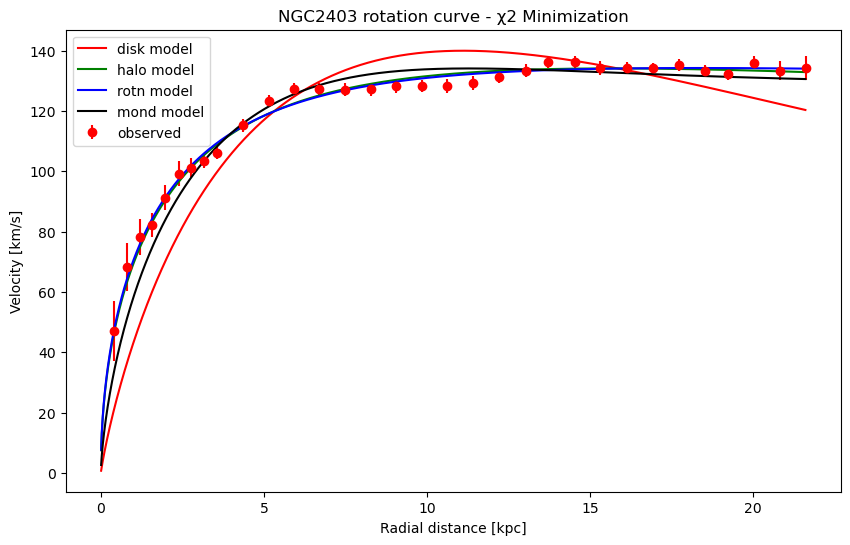

In [260]:
# Chi2 Minimization for data
# define data set here
data = NGC2
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# diskmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100

prior_bounds_disk = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_disk = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# halomodel
# Rhalo
min0, max0 = 0, 100
# Mhalo
min1, max1 = 0, 100

prior_bounds_halo = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_halo = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# rotnmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# Rhalo
min2, max2 = 0, 100
# Mhalo
min3, max3 = 0, 100

prior_bounds_rotn = np.array([[min0, min1, min2, min3],
                              [max0, max1, max2, max3]])
initial_guess_rotn = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2),
                      np.random.uniform(min3,max3)]

# mondmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# acrit
min2, max2 = 0, 100

prior_bounds_mond = np.array([[min0, min1, min2],
                              [max0, max1, max2]])
initial_guess_mond = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2)]

# Get the best fitting parameters for diskmodel
diskBest, diskcov = curve_fit(diskmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_disk,bounds=prior_bounds_disk,
                              maxfev=1000)

# Get the best fitting parameters for halomodel
haloBest, halocov = curve_fit(halomodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_halo,bounds=prior_bounds_halo,
                              maxfev=1000)

# Get the best fitting parameters for rotnmodel
rotnBest, rotncov = curve_fit(rotnmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_rotn,bounds=prior_bounds_rotn,
                              maxfev=1000)

# Get the best fitting parameters for mondmodel
mondBest, mondcov = curve_fit(mondmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_mond,bounds=prior_bounds_mond,
                              maxfev=1000)
# disk model chi2
disk = 0.0
for i in range(len(data)):
    disk = disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2
loglike_disk = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*disk
    

# halo model chi2
halo = 0.0
for i in range(len(data)):
    halo = halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
loglike_halo = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*halo

# rotn model chi2
rotn = 0.0
for i in range(len(data)):
    rotn = rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
loglike_rotn = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*rotn

# mond model chi2
mond = 0.0
for i in range(len(data)):
    mond = mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2
loglike_mond = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*mond

# disk model chi2
chi2_red_disk = 0.0
for i in range(len(data)):
    chi2_red_disk = chi2_red_disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2    
# halo model chi2
chi2_red_halo = 0.0
for i in range(len(data)):
    chi2_red_halo = chi2_red_halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
# rotn model chi2
chi2_red_rotn = 0.0
for i in range(len(data)):
    chi2_red_rotn = chi2_red_rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
# mond model chi2
chi2_red_mond = 0.0
for i in range(len(data)):
    chi2_red_mond = chi2_red_mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2

# Calculate the reduced chi2
chi2_red_disk = chi2_red_disk / (len(data)-len(diskBest))
chi2_red_halo = chi2_red_halo / (len(data)-len(haloBest))
chi2_red_rotn = chi2_red_rotn / (len(data)-len(rotnBest))
chi2_red_mond = chi2_red_mond / (len(data)-len(mondBest))

# Calculate the BIC and AIC
bic_disk = -2 * loglike_disk + len(diskBest) * np.log(len(data))
aic_disk = -2 * loglike_disk + 2 * len(diskBest)

bic_halo = -2 * loglike_halo + len(haloBest) * np.log(len(data))
aic_halo = -2 * loglike_halo + 2 * len(haloBest)

bic_rotn = -2 * loglike_rotn + len(rotnBest) * np.log(len(data))
aic_rotn = -2 * loglike_rotn + 2 * len(rotnBest)

bic_mond = -2 * loglike_mond + len(mondBest) * np.log(len(data))
aic_mond = -2 * loglike_mond + 2 * len(mondBest)

print("~disk model~")
print("best Rdisk:\t", np.round(diskBest[0],2))
print("best Mdisk:\t", np.round(diskBest[1],2))
print("χ2 Min:\t\t", np.round(disk,2))
print("Red. χ2:\t", np.round(chi2_red_disk,2))
print("BIC:\t\t", np.round(bic_disk,2))
print("AIC:\t\t", np.round(aic_disk,2))
print()
print("~halo model~")
print("best Rhalo:\t", np.round(haloBest[0],2))
print("best Mhalo:\t", np.round(haloBest[1],2))
print("χ2 Min:\t\t", np.round(halo,2))
print("Red. χ2:\t", np.round(chi2_red_halo,2))
print("BIC:\t\t", np.round(bic_halo,2))
print("AIC:\t\t", np.round(aic_halo,2))
print()
print("~rotn model~")
print("best Rdisk:\t", np.round(rotnBest[0],2))
print("best Mdisk:\t", np.round(rotnBest[1],2))
print("best Rhalo:\t", np.round(rotnBest[2],2))
print("best Mhalo:\t", np.round(rotnBest[3],2))
print("χ2 Min:\t\t", np.round(rotn,2))
print("Red. χ2:\t", np.round(chi2_red_rotn,2))
print("BIC:\t\t", np.round(bic_rotn,2))
print("AIC:\t\t", np.round(aic_rotn,2))
print()
print("~mond model~")
print("best Rdisk:\t", np.round(mondBest[0],2))
print("best Mdisk:\t", np.round(mondBest[1],2))
print("best acrit:\t", np.round(mondBest[2],2))
print("χ2 Min:\t\t", np.round(mond,2))
print("Red. χ2:\t", np.round(chi2_red_mond,2))
print("BIC:\t\t", np.round(bic_mond,2))
print("AIC:\t\t", np.round(aic_mond,2))

diskcurve = diskmodel(Rdense,diskBest[0],diskBest[1])
halocurve = halomodel(Rdense,haloBest[0],haloBest[1])
rotncurve = rotnmodel(Rdense,rotnBest[0],rotnBest[1],rotnBest[2],rotnBest[3])
mondcurve = mondmodel(Rdense,mondBest[0],mondBest[1],mondBest[2])

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("NGC2403 rotation curve - χ2 Minimization")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, diskcurve,'r-', label='disk model')
plt.plot(Rdense, halocurve,'g-', label='halo model')
plt.plot(Rdense, rotncurve,'b-', label='rotn model')
plt.plot(Rdense, mondcurve,'k-', label='mond model')
plt.legend()
plt.show()

~disk model~
best Rdisk:	 5.84
best Mdisk:	 95.81
χ2 Min:		 607.66
Red. χ2:	 23.37
BIC:		 721.33
AIC:		 718.67

~halo model~
best Rhalo:	 5.43
best Mhalo:	 27.15
χ2 Min:		 52.52
Red. χ2:	 2.02
BIC:		 166.18
AIC:		 163.52

~rotn model~
best Rdisk:	 45.67
best Mdisk:	 100.0
best Rhalo:	 4.88
best Mhalo:	 23.67
χ2 Min:		 48.28
Red. χ2:	 2.01
BIC:		 168.61
AIC:		 163.28

~mond model~
best Rdisk:	 2.15
best Mdisk:	 12.46
best acrit:	 2.82
χ2 Min:		 12.8
Red. χ2:	 0.51
BIC:		 129.8
AIC:		 125.81


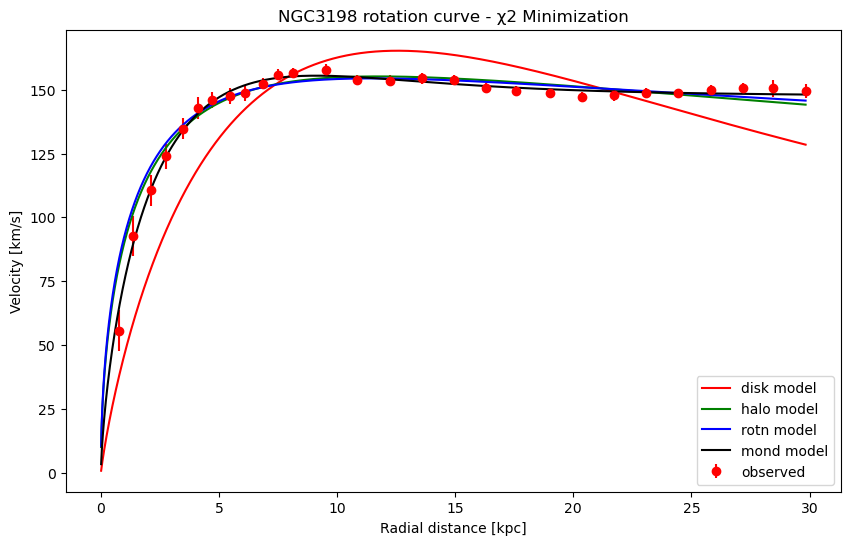

In [256]:
# Chi2 Minimization for data
# define data set here
data = NGC3
Rdense = np.arange(0.01,data[:,0][-1],0.01)

# diskmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100

prior_bounds_disk = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_disk = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# halomodel
# Rhalo
min0, max0 = 0, 100
# Mhalo
min1, max1 = 0, 100

prior_bounds_halo = np.array([[min0, min1],
                              [max0, max1]])
initial_guess_halo = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1)]

# rotnmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# Rhalo
min2, max2 = 0, 100
# Mhalo
min3, max3 = 0, 100

prior_bounds_rotn = np.array([[min0, min1, min2, min3],
                              [max0, max1, max2, max3]])
initial_guess_rotn = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2),
                      np.random.uniform(min3,max3)]

# mondmodel
# Rdisk
min0, max0 = 0, 100
# Mdisk
min1, max1 = 0, 100
# acrit
min2, max2 = 0, 100

prior_bounds_mond = np.array([[min0, min1, min2],
                              [max0, max1, max2]])
initial_guess_mond = [np.random.uniform(min0,max0),
                      np.random.uniform(min1,max1),
                      np.random.uniform(min2,max2)]

# Get the best fitting parameters for diskmodel
diskBest, diskcov = curve_fit(diskmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_disk,bounds=prior_bounds_disk,
                              maxfev=1000)

# Get the best fitting parameters for halomodel
haloBest, halocov = curve_fit(halomodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_halo,bounds=prior_bounds_halo,
                              maxfev=1000)

# Get the best fitting parameters for rotnmodel
rotnBest, rotncov = curve_fit(rotnmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_rotn,bounds=prior_bounds_rotn,
                              maxfev=1000)

# Get the best fitting parameters for mondmodel
mondBest, mondcov = curve_fit(mondmodel,data[:,0],
                              data[:,1],sigma=data[:,2],
                              p0=initial_guess_mond,bounds=prior_bounds_mond,
                              maxfev=1000)
# disk model chi2
disk = 0.0
for i in range(len(data)):
    disk = disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2
loglike_disk = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*disk
    

# halo model chi2
halo = 0.0
for i in range(len(data)):
    halo = halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
loglike_halo = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*halo

# rotn model chi2
rotn = 0.0
for i in range(len(data)):
    rotn = rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
loglike_rotn = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*rotn

# mond model chi2
mond = 0.0
for i in range(len(data)):
    mond = mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2
loglike_mond = -0.5*len(data)*np.log(2.0*np.pi) - np.sum(np.log(data[:,2])) - 0.5*mond

# disk model chi2
chi2_red_disk = 0.0
for i in range(len(data)):
    chi2_red_disk = chi2_red_disk + ((data[i,1] - diskmodel(data[i,0],
                                          diskBest[0],
                                          diskBest[1])) / data[i,2])**2    
# halo model chi2
chi2_red_halo = 0.0
for i in range(len(data)):
    chi2_red_halo = chi2_red_halo + ((data[i,1] - halomodel(data[i,0],
                                          haloBest[0],
                                          haloBest[1])) / data[i,2])**2
# rotn model chi2
chi2_red_rotn = 0.0
for i in range(len(data)):
    chi2_red_rotn = chi2_red_rotn + ((data[i,1] - rotnmodel(data[i,0],
                                          rotnBest[0],
                                          rotnBest[1],
                                          rotnBest[2],
                                          rotnBest[3])) / data[i,2])**2
# mond model chi2
chi2_red_mond = 0.0
for i in range(len(data)):
    chi2_red_mond = chi2_red_mond + ((data[i,1] - mondmodel(data[i,0],
                                          mondBest[0],
                                          mondBest[1],
                                          mondBest[2])) / data[i,2])**2

# Calculate the reduced chi2
chi2_red_disk = chi2_red_disk / (len(data)-len(diskBest))
chi2_red_halo = chi2_red_halo / (len(data)-len(haloBest))
chi2_red_rotn = chi2_red_rotn / (len(data)-len(rotnBest))
chi2_red_mond = chi2_red_mond / (len(data)-len(mondBest))

# Calculate the BIC and AIC
bic_disk = -2 * loglike_disk + len(diskBest) * np.log(len(data))
aic_disk = -2 * loglike_disk + 2 * len(diskBest)

bic_halo = -2 * loglike_halo + len(haloBest) * np.log(len(data))
aic_halo = -2 * loglike_halo + 2 * len(haloBest)

bic_rotn = -2 * loglike_rotn + len(rotnBest) * np.log(len(data))
aic_rotn = -2 * loglike_rotn + 2 * len(rotnBest)

bic_mond = -2 * loglike_mond + len(mondBest) * np.log(len(data))
aic_mond = -2 * loglike_mond + 2 * len(mondBest)

print("~disk model~")
print("best Rdisk:\t", np.round(diskBest[0],2))
print("best Mdisk:\t", np.round(diskBest[1],2))
print("χ2 Min:\t\t", np.round(disk,2))
print("Red. χ2:\t", np.round(chi2_red_disk,2))
print("BIC:\t\t", np.round(bic_disk,2))
print("AIC:\t\t", np.round(aic_disk,2))
print()
print("~halo model~")
print("best Rhalo:\t", np.round(haloBest[0],2))
print("best Mhalo:\t", np.round(haloBest[1],2))
print("χ2 Min:\t\t", np.round(halo,2))
print("Red. χ2:\t", np.round(chi2_red_halo,2))
print("BIC:\t\t", np.round(bic_halo,2))
print("AIC:\t\t", np.round(aic_halo,2))
print()
print("~rotn model~")
print("best Rdisk:\t", np.round(rotnBest[0],2))
print("best Mdisk:\t", np.round(rotnBest[1],2))
print("best Rhalo:\t", np.round(rotnBest[2],2))
print("best Mhalo:\t", np.round(rotnBest[3],2))
print("χ2 Min:\t\t", np.round(rotn,2))
print("Red. χ2:\t", np.round(chi2_red_rotn,2))
print("BIC:\t\t", np.round(bic_rotn,2))
print("AIC:\t\t", np.round(aic_rotn,2))
print()
print("~mond model~")
print("best Rdisk:\t", np.round(mondBest[0],2))
print("best Mdisk:\t", np.round(mondBest[1],2))
print("best acrit:\t", np.round(mondBest[2],2))
print("χ2 Min:\t\t", np.round(mond,2))
print("Red. χ2:\t", np.round(chi2_red_mond,2))
print("BIC:\t\t", np.round(bic_mond,2))
print("AIC:\t\t", np.round(aic_mond,2))

diskcurve = diskmodel(Rdense,diskBest[0],diskBest[1])
halocurve = halomodel(Rdense,haloBest[0],haloBest[1])
rotncurve = rotnmodel(Rdense,rotnBest[0],rotnBest[1],rotnBest[2],rotnBest[3])
mondcurve = mondmodel(Rdense,mondBest[0],mondBest[1],mondBest[2])

plt.rcParams.update(plt.rcParamsDefault)
fig = plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2],fmt='ro', label='observed')
plt.title("NGC3198 rotation curve - χ2 Minimization")
plt.xlabel('Radial distance [kpc]')
plt.ylabel('Velocity [km/s]')
plt.plot(Rdense, diskcurve,'r-', label='disk model')
plt.plot(Rdense, halocurve,'g-', label='halo model')
plt.plot(Rdense, rotncurve,'b-', label='rotn model')
plt.plot(Rdense, mondcurve,'k-', label='mond model')
plt.legend()
plt.show()

In [199]:
# Define the log likelihood function
def log_likelihood(data, model_func, best_params):
    residuals = (data[:,1] - model_func(data[:,0], *best_params)) / data[:,2]
    return -0.5 * np.sum(residuals ** 2 + np.log(2 * np.pi * data[:,2] **2))

bic_values = []
aic_values = []

# Calculate the BIC and AIC for each model
bic_disk = -2 * loglike_disk + len(diskBest) * np.log(len(data))
aic_disk = -2 * loglike_disk + 2 * len(diskBest)

bic_halo = -2 * loglike_halo + len(haloBest) * np.log(len(data))
aic_halo = -2 * loglike_halo + 2 * len(haloBest)

bic_rotn = -2 * loglike_rotn + len(rotnBest) * np.log(len(data))
aic_rotn = -2 * loglike_rotn + 2 * len(rotnBest)

bic_mond = -2 * loglike_mond + len(mondBest) * np.log(len(data))
aic_mond = -2 * loglike_mond + 2 * len(mondBest)

# Define the number of sigma confidence level
sigma = 5

# Calculate the critical BIC and AIC values for model comparison
bic_threshold = np.min([bic_disk, bic_halo, bic_rotn, bic_mond]) + sigma * np.log(len(data))
aic_threshold = np.min([aic_disk, aic_halo, aic_rotn, aic_mond]) + 2 * sigma

# Determine the minimum data required to distinguish the models
acceptable_data_size = None
for n in range(len(data), 0, -1):
    # Generate a hypothetical dataset with smaller errors or higher sampling
    hypothetical_data = np.copy(data)
    hypothetical_data[:,2] /= np.sqrt(n / len(data))  # Decrease errors by n
    
    # Perform model fitting with the hypothetical dataset
    diskBest_hyp, _ = curve_fit(diskmodel, hypothetical_data[:,0], hypothetical_data[:,1],
                                sigma=hypothetical_data[:,2], p0=initial_guess_disk,
                                bounds=prior_bounds_disk, maxfev=1000)
    haloBest_hyp, _ = curve_fit(halomodel, hypothetical_data[:,0], hypothetical_data[:,1],
                                sigma=hypothetical_data[:,2], p0=initial_guess_halo,
                                bounds=prior_bounds_halo, maxfev=1000)
    rotnBest_hyp, _ = curve_fit(rotnmodel, hypothetical_data[:,0], hypothetical_data[:,1],
                                sigma=hypothetical_data[:,2], p0=initial_guess_rotn,
                                bounds=prior_bounds_rotn, maxfev=1000)
    mondBest_hyp, _ = curve_fit(mondmodel, hypothetical_data[:,0], hypothetical_data[:,1],
                                sigma=hypothetical_data[:,2], p0=initial_guess_mond,
                                bounds=prior_bounds_mond, maxfev=1000)
    
    # Calculate the log likelihoods for the hypothetical dataset
    loglike_disk_hyp = log_likelihood(hypothetical_data, diskmodel, diskBest_hyp)
    loglike_halo_hyp = log_likelihood(hypothetical_data, halomodel, haloBest_hyp)
    loglike_rotn_hyp = log_likelihood(hypothetical_data, rotnmodel, rotnBest_hyp)
    loglike_mond_hyp = log_likelihood(hypothetical_data, mondmodel, mondBest_hyp)

    # Calculate the BIC and AIC for the hypothetical dataset
    bic_disk_hyp = -2 * loglike_disk_hyp + len(diskBest_hyp) * np.log(len(hypothetical_data))
    aic_disk_hyp = -2 * loglike_disk_hyp + 2 * len(diskBest_hyp)
    bic_halo_hyp = -2 * loglike_halo_hyp + len(haloBest_hyp) * np.log(len(hypothetical_data))
    aic_halo_hyp = -2 * loglike_halo_hyp + 2 * len(haloBest_hyp)
    bic_rotn_hyp = -2 * loglike_rotn_hyp + len(rotnBest_hyp) * np.log(len(hypothetical_data))
    aic_rotn_hyp = -2 * loglike_rotn_hyp + 2 * len(rotnBest_hyp)
    bic_mond_hyp = -2 * loglike_mond_hyp + len(mondBest_hyp) * np.log(len(hypothetical_data))
    aic_mond_hyp = -2 * loglike_mond_hyp + 2 * len(mondBest_hyp)

    print("iteration", n)
    print("Results for Hypothetical Dataset:")
    print("BIC (Disk):", np.round(bic_disk_hyp,2))
    print("AIC (Disk):", np.round(aic_disk_hyp,2))
    
    print("BIC (Halo):", np.round(bic_halo_hyp,2))
    print("AIC (Halo):", np.round(aic_halo_hyp,2))
    
    print("BIC (Rotn):", np.round(bic_rotn_hyp,2))
    print("AIC (Rotn):", np.round(aic_rotn_hyp,2))
    
    print("BIC (Mond):", np.round(bic_mond_hyp,2))
    print("AIC (Mond):", np.round(aic_mond_hyp,2))

    if bic_disk_hyp > bic_threshold and bic_halo_hyp > bic_threshold and bic_rotn_hyp > bic_threshold and bic_mond_hyp > bic_threshold:
        print("Hypothetical model is favored based on BIC.")
    elif aic_disk_hyp > aic_threshold and aic_halo_hyp > aic_threshold and aic_rotn_hyp > aic_threshold and aic_mond_hyp > aic_threshold:
        print("Hypothetical model is favored based on AIC.")
    else:
        print("Hypothetical model is not favored based on BIC or AIC.")
        
    print()
    
    # Append BIC and AIC values to the lists
    bic_values.append([n, bic_disk_hyp, bic_halo_hyp, bic_rotn_hyp, bic_mond_hyp])
    aic_values.append([n, aic_disk_hyp, aic_halo_hyp, aic_rotn_hyp, aic_mond_hyp])

# Convert the lists to arrays for plotting
bic_values = np.array(bic_values)
aic_values = np.array(aic_values)

iteration 28
Results for Hypothetical Dataset:
BIC (Disk): 721.33
AIC (Disk): 718.67
BIC (Halo): 166.18
AIC (Halo): 163.52
BIC (Rotn): 168.61
AIC (Rotn): 163.28
BIC (Mond): 129.8
AIC (Mond): 125.81
Hypothetical model is not favored based on BIC or AIC.

iteration 27
Results for Hypothetical Dataset:
BIC (Disk): 700.65
AIC (Disk): 697.98
BIC (Halo): 165.33
AIC (Halo): 162.66
BIC (Rotn): 167.9
AIC (Rotn): 162.57
BIC (Mond): 130.36
AIC (Mond): 126.37
Hypothetical model is not favored based on BIC or AIC.

iteration 26
Results for Hypothetical Dataset:
BIC (Disk): 680.0
AIC (Disk): 677.34
BIC (Halo): 164.51
AIC (Halo): 161.84
BIC (Rotn): 167.24
AIC (Rotn): 161.91
BIC (Mond): 130.96
AIC (Mond): 126.97
Hypothetical model is not favored based on BIC or AIC.

iteration 25
Results for Hypothetical Dataset:
BIC (Disk): 659.4
AIC (Disk): 656.73
BIC (Halo): 163.73
AIC (Halo): 161.07
BIC (Rotn): 166.61
AIC (Rotn): 161.28
BIC (Mond): 131.6
AIC (Mond): 127.61
Hypothetical model is not favored based o

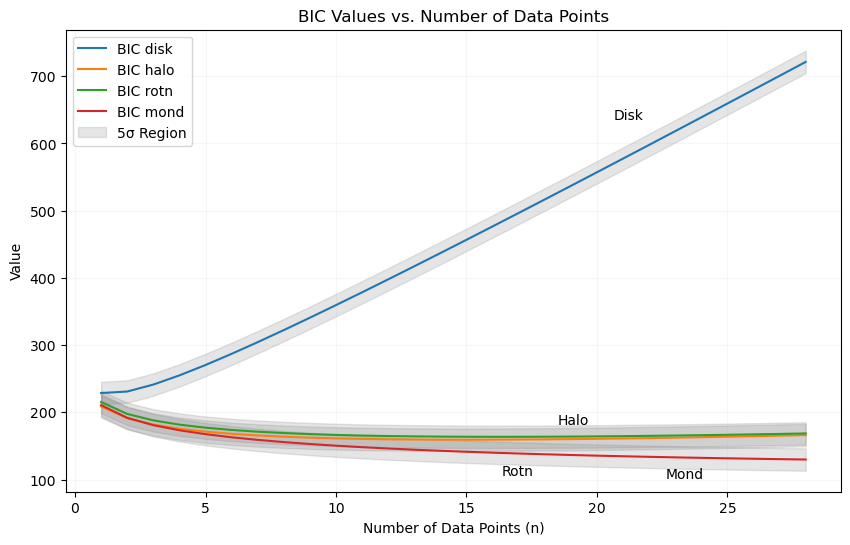

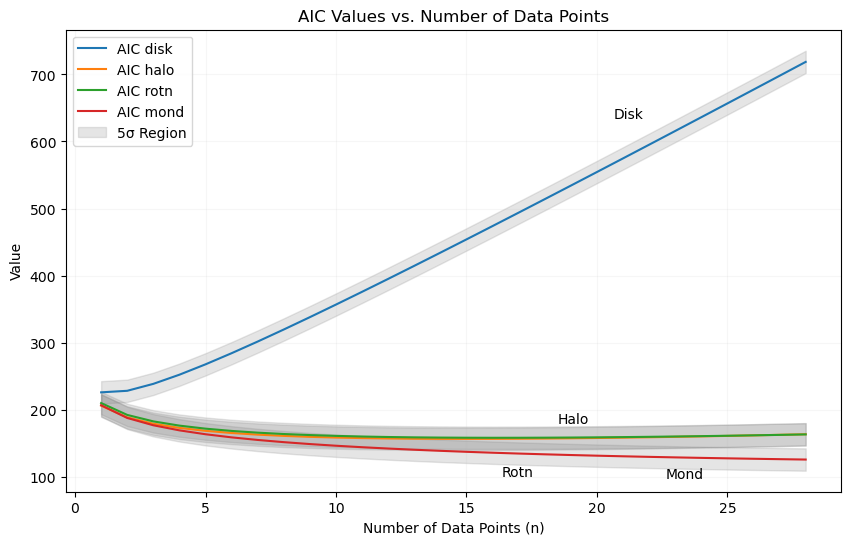

In [200]:
plt.rcParams.update(plt.rcParamsDefault)

# Convert the lists to arrays for plotting
bic_values = np.array(bic_values)
aic_values = np.array(aic_values)

# Plot BIC values
plt.figure(figsize=(10, 6))
plt.plot(bic_values[:, 0], bic_values[:, 1], label='BIC disk')
plt.plot(bic_values[:, 0], bic_values[:, 2], label='BIC halo')
plt.plot(bic_values[:, 0], bic_values[:, 3], label='BIC rotn')
plt.plot(bic_values[:, 0], bic_values[:, 4], label='BIC mond')

# Add labels pointing to each curve
label_offsets = [(380, 200), (340, -10), (300, -50), (420, -50)]  # Adjust the offsets as needed
for i, model in enumerate(['Disk', 'Halo', 'Rotn', 'Mond']):
    plt.annotate(model, (bic_values[-1, 0], bic_values[-1, i + 1]), xytext=label_offsets[i],
                 textcoords='offset points', ha='center', va='center')

# Add 5-sigma confidence regions for BIC values
for i in range(1, 5):
    plt.fill_between(bic_values[:, 0], bic_values[:, i] - sigma * np.log(len(data)),
                     bic_values[:, i] + sigma * np.log(len(data)), alpha=0.2, color='grey')
    
plt.fill_between([], [], [], alpha=0.2, color='grey', label='5σ Region')
plt.xlabel('Number of Data Points (n)')
plt.ylabel('Value')
plt.title('BIC Values vs. Number of Data Points')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

# Plot AIC values
plt.figure(figsize=(10, 6))
plt.plot(aic_values[:, 0], aic_values[:, 1], label='AIC disk')
plt.plot(aic_values[:, 0], aic_values[:, 2], label='AIC halo')
plt.plot(aic_values[:, 0], aic_values[:, 3], label='AIC rotn')
plt.plot(aic_values[:, 0], aic_values[:, 4], label='AIC mond')

# Add labels pointing to each curve
for i, model in enumerate(['Disk', 'Halo', 'Rotn', 'Mond']):
    plt.annotate(model, (aic_values[-1, 0], aic_values[-1, i + 1]), xytext=label_offsets[i],
                 textcoords='offset points', ha='center', va='center')

# Add 5-sigma confidence regions for AIC values
for i in range(1, 5):
    plt.fill_between(aic_values[:, 0], aic_values[:, i] - sigma * np.log(len(data)),
                     aic_values[:, i] + sigma * np.log(len(data)), alpha=0.2, color='grey')

plt.fill_between([], [], [], alpha=0.2, color='grey', label='5σ Region')
plt.xlabel('Number of Data Points (n)')
plt.ylabel('Value')
plt.title('AIC Values vs. Number of Data Points')
plt.legend()
plt.grid(alpha=0.1)
plt.show()